<a href="https://colab.research.google.com/github/marielaAriass/YeastMat/blob/main/profundidad/boxplots_profundidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# Funciones

## Dataframe y filtrar

In [71]:
def crear_df(archivo_profundidad):
    columnas = ["NombreCepa", "posicion", "profundidad"]
    df = pd.read_csv(archivo_profundidad, delimiter="\t", names=columnas)
    df['NombreCepa'] = df['NombreCepa'].str.rstrip('-')
    df['Cepa'] = df['NombreCepa'].str.split('_').str[0]
    df['Region'] = df['NombreCepa'].str.split('_').str[-1]
    df['Gen'] = df['NombreCepa'].str.extract(r'_(X|Z|Z2|Ya|Yalpha|W|w)_')

    archivo_clados = 'cepas_iguales.csv'

    df_clado = pd.read_csv(archivo_clados)
    df['NombreCepa'] = df['NombreCepa'].astype(str)
    df_clado['FASTA'] = df_clado['FASTA'].astype(str)

    # Realizar el merge entre 'df' y 'df_clado' en base a 'NombreCepa' y 'FASTA'
    merged_df = df.merge(df_clado[['FASTA', 'CLADO']], left_on='NombreCepa', right_on='FASTA', how='left')

    # Fill NaN values in 'CLADO' with an empty string before concatenation
    merged_df['CLADO'] = merged_df['CLADO'].fillna('').astype(str)

    # Crear la columna 'Nombre' con el formato deseado
    merged_df['Nombre'] = merged_df['NombreCepa'] + ' - ' + merged_df['CLADO']

    # Actualizar 'df' para incluir la nueva columna 'Nombre'
    df['Nombre'] = merged_df['Nombre']

    # Crear la columna 'Clado' desde 'Nombre'
    # Ensure 'Nombre' is string type and handle NaN before splitting
    df['Clado'] = df['Nombre'].fillna('').astype(str).str.split('-').str[-1].str.strip()

    # Crear la columna 'Especie' según el clado
    # 'Clado' is now guaranteed to be a string due to fillna('') and astype(str)
    df['Especie'] = df['Clado'].apply(lambda x: 'Paradoxus' if x == 'Paradoxus' else 'Cerevisiae')

    df = df[~df['Cepa'].str.contains('CEI')]

    return df

In [ ]:
def df_genesY(df):
    # Filtrar solo los genes Ya y Yalpha
    genes_y = df[df['Gen'].isin(['Ya', 'Yalpha'])].copy()

    # Crear columna posicionNueva basada en Gen
    genes_y['posicionNueva'] = genes_y['posicion']
    genes_y.loc[genes_y['Gen'] == 'Ya', 'posicionNueva'] = genes_y['posicion'] + 749

    return genes_y


## Graficas

In [ ]:
def plot_especie_boxplot2(genes_y, hibrido):
    """
    Grafica la profundidad de genes Ya y Yalpha por especie utilizando box plot.
    Regresa fig y ax para poder integrarlo en subplots.
    """

    # Agrupar datos
    grupo_suma = genes_y.groupby(['posicionNueva', 'Gen', 'Especie'])['profundidad'].sum().reset_index()

    # Crear figura y eje
    fig, ax = plt.subplots(figsize=(12, 8))

    # Boxplot
    try:
        sns.boxplot(
            x='Gen', y='profundidad', hue='Especie', data=grupo_suma,
            palette={'Cerevisiae': '#FFA500', 'Paradoxus': '#1E90FF'},
            showfliers=False, ax=ax
        )
    except ValueError as e:
        print(f"Error en los datos: {e}")
        return None, None

    # Personalización
    ax.set_title(f'Profundidad de genes Ya y Yalpha por especie del híbrido {hibrido}', fontsize=14)
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_ylabel('Suma de Profundidad', fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(title='Especie', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Crear carpeta
    out_dir = 'Imagenes/boxplots/'
    os.makedirs(out_dir, exist_ok=True)

    # Guardar imagen
    fig.tight_layout()
    fig.savefig(f'{out_dir}{hibrido}_BOXPLOT.png', dpi=300, bbox_inches="tight")

    return fig, ax


## Descomprimir / crear carpeta

In [ ]:
def descomprimir(carpeta_comprimida, carpeta_descomprimida):
  zip_file_path = carpeta_comprimida
  extract_dir = carpeta_descomprimida
  os.makedirs(extract_dir, exist_ok=True)

  # Descomprimir el archivo
  !unzip -o "{zip_file_path}" -d "{extract_dir}"

  print(f"'{zip_file_path}' ha sido descomprimido en '{extract_dir}'")

In [ ]:
#crear carptea
os.makedirs('Imagenes/boxplots', exist_ok=True)
print("Carpeta 'Imagenes/boxplots' creada exitosamente o ya existente.")

Carpeta 'Imagenes/boxplots' creada exitosamente o ya existente.


## PROCESAR TODOS LOS ARCHIVOS

In [38]:
def metodo_lociConcatenado(ruta_zip, carpeta_destino, archivo_familias):
    """
    Descomprime un ZIP, carga familias, procesa archivos .tsv y genera boxplots.

    Parámetros:
        ruta_zip (str): Ruta del archivo .zip a descomprimir.
        carpeta_destino (str): Carpeta donde se descomprime el ZIP.
        archivo_familias (str): CSV con columnas ID y FAMILIA.

    Retorna:
        diccionario con: {hibrido: figura_generada}
    """

    # --- 1) Descomprimir ---
    descomprimir(ruta_zip, carpeta_destino)

    # Carpeta interna final con los .tsv
    # Se asume que el directorio interno tiene el mismo nombre que la carpeta_destino
    carpeta_tsv = os.path.join(carpeta_destino, os.path.basename(carpeta_destino))

    # --- 2) Cargar familias ---
    df_familias = pd.read_csv(archivo_familias)
    dic_familias = dict(zip(df_familias["ID"], df_familias["FAMILIA"]))

    # --- 3) Procesar archivos ---
    archivos = [f for f in os.listdir(carpeta_tsv) if f.endswith('.tsv')]
    resultados = {}

    for archivo in archivos:
        ruta = os.path.join(carpeta_tsv, archivo)

        # nombre base sin extension
        nombre = os.path.splitext(archivo)[0]   # ejemplo: depth_YMX004605
        hibrido = nombre.replace("depth_", "")  # queda YMX004605

        # buscar familia
        familia = dic_familias.get(hibrido, "FAMILIA_DESCONOCIDA")

        # cargar dataframes
        df = crear_df(ruta)
        genesY = df_genesY(df)

        # nombre mostrado en la figura
        nombre_mostrar = f"{hibrido} (Familia: {familia})"

        # generar figura
        plot = plot_especie_boxplot2(genesY, nombre_mostrar)

        # guardar en el diccionario
        resultados[hibrido] = plot

    return resultados

## SUBPLOTS

In [111]:
def generar_subplots(carpeta_tsv, archivo_familias):
    """
    Genera subplots ordenados por familia con boxplots para todos los archivos .tsv.
    Incluye la familia del híbrido en los títulos.

    Parámetros:
        carpeta_tsv (str): Carpeta donde están los .tsv
        archivo_familias (str): CSV con columnas ID y FAMILIA

    Retorna:
        fig: figura con todos los subplots generados
    """

    import os
    import math
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # ----------------------------------------------------------
    # 1) Cargar archivo de familias
    # ----------------------------------------------------------
    df_familias = pd.read_csv(archivo_familias)

    # Diccionario ID → FAMILIA
    dic_familias = dict(zip(df_familias["ID"], df_familias["FAMILIA"]))

    # ----------------------------------------------------------
    # 2) Función local para preparar datos
    # ----------------------------------------------------------
    def preparar_datos_boxplot(genes_y):
        grupo_suma = genes_y.groupby(
            ['posicionNueva', 'Gen', 'Especie']
        )['profundidad'].sum().reset_index()
        return grupo_suma

    # ----------------------------------------------------------
    # 3) Cargar y procesar archivos
    # ----------------------------------------------------------
    archivos = [f for f in os.listdir(carpeta_tsv) if f.endswith('.tsv')]
    datos_list = []

    for archivo in archivos:
        ruta = os.path.join(carpeta_tsv, archivo)
        nombre = os.path.splitext(archivo)[0]
        nombre_limpio = nombre.replace("depth_", "")

        # Familia
        familia = dic_familias.get(nombre_limpio, "FAMILIA_DESCONOCIDA")

        # Texto mostrado en el subplot
        nombre_mostrar = f"{nombre_limpio} (Familia: {familia})"

        df = crear_df(ruta)
        genesY = df_genesY(df)
        datos = preparar_datos_boxplot(genesY)

        datos_list.append((familia, nombre_limpio, nombre_mostrar, datos))

    # ----------------------------------------------------------
    # 4) ORDENAR subplots por FAMILIA
    # ----------------------------------------------------------
    datos_list.sort(key=lambda x: (x[0], x[1]))
    # Orden: primero familia, luego ID

    # ----------------------------------------------------------
    # 5) Crear subplots
    # ----------------------------------------------------------
    n = len(datos_list)
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axs = axs.flatten()

    fig.suptitle(
        "Profundidad de triploides - Método de referencia concatenada por loci",
        fontsize=18,
        weight='bold',
        y=1.02
    )

    for i, (familia, nombre_limpio, nombre_mostrar, datos) in enumerate(datos_list):
        ax = axs[i]

        sns.boxplot(
            x='Gen', y='profundidad', hue='Especie', data=datos,
            palette={'Cerevisiae': '#FFA500', 'Paradoxus': '#1E90FF'},
            showfliers=False, ax=ax
        )

        ax.set_title(nombre_mostrar)
        ax.set_xlabel('Gen')
        ax.set_ylabel('Profundidad')
        ax.grid(alpha=0.3)

        # Quitar leyenda en todos menos el primero
        if i != 0:
            leg = ax.get_legend()
            if leg:
                leg.remove()

    # Ocultar subplots vacíos
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

    return fig


# METODO 1 - REFERENCIA CONCATENADA POR LOCI

## Diploides - Metodo 1: referencia concatenada por loci

Archive:  /content/PROF_DIPLOIDES.zip
  inflating: /content/PROF_DIPLOIDES/PROF_DIPLOIDES/depth_YMX004605.tsv  
  inflating: /content/PROF_DIPLOIDES/PROF_DIPLOIDES/depth_YMX004655.tsv  
  inflating: /content/PROF_DIPLOIDES/PROF_DIPLOIDES/depth_YMX005579.tsv  
  inflating: /content/PROF_DIPLOIDES/PROF_DIPLOIDES/depth_YMX005605.tsv  
  inflating: /content/PROF_DIPLOIDES/PROF_DIPLOIDES/depth_YMX506F06.tsv  
'/content/PROF_DIPLOIDES.zip' ha sido descomprimido en '/content/PROF_DIPLOIDES'


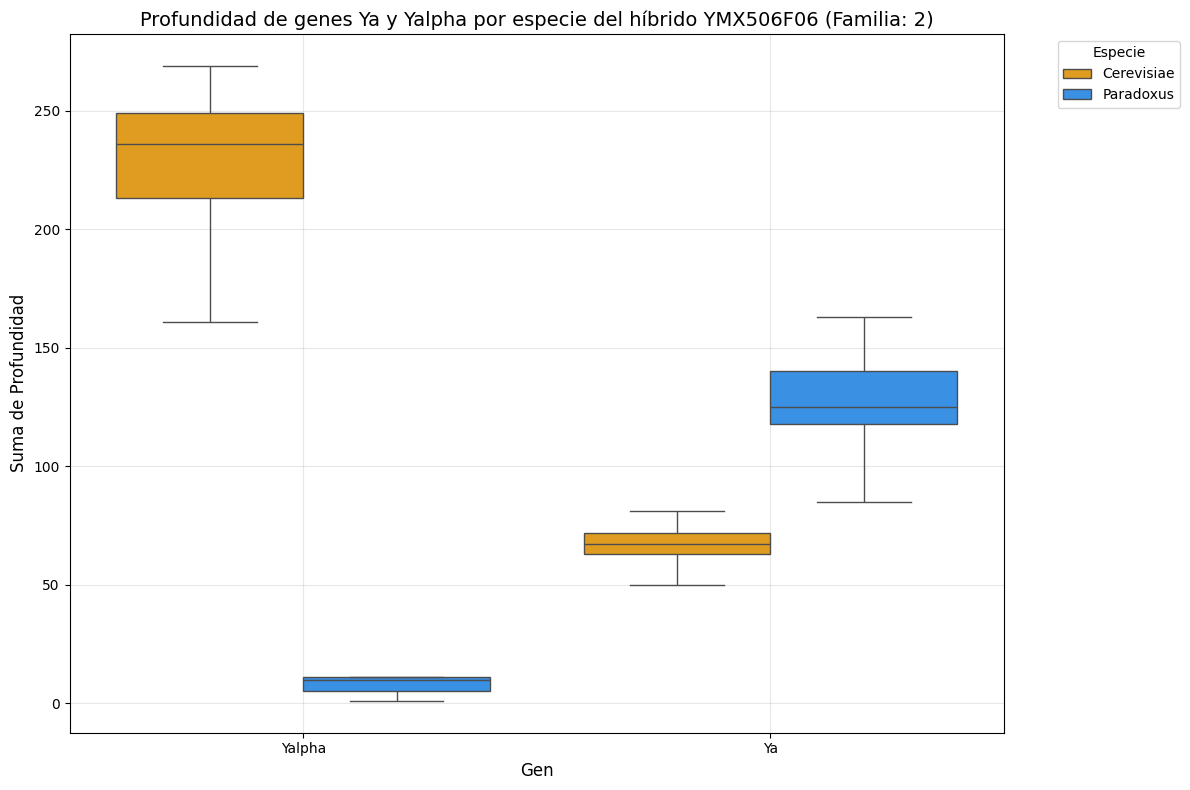

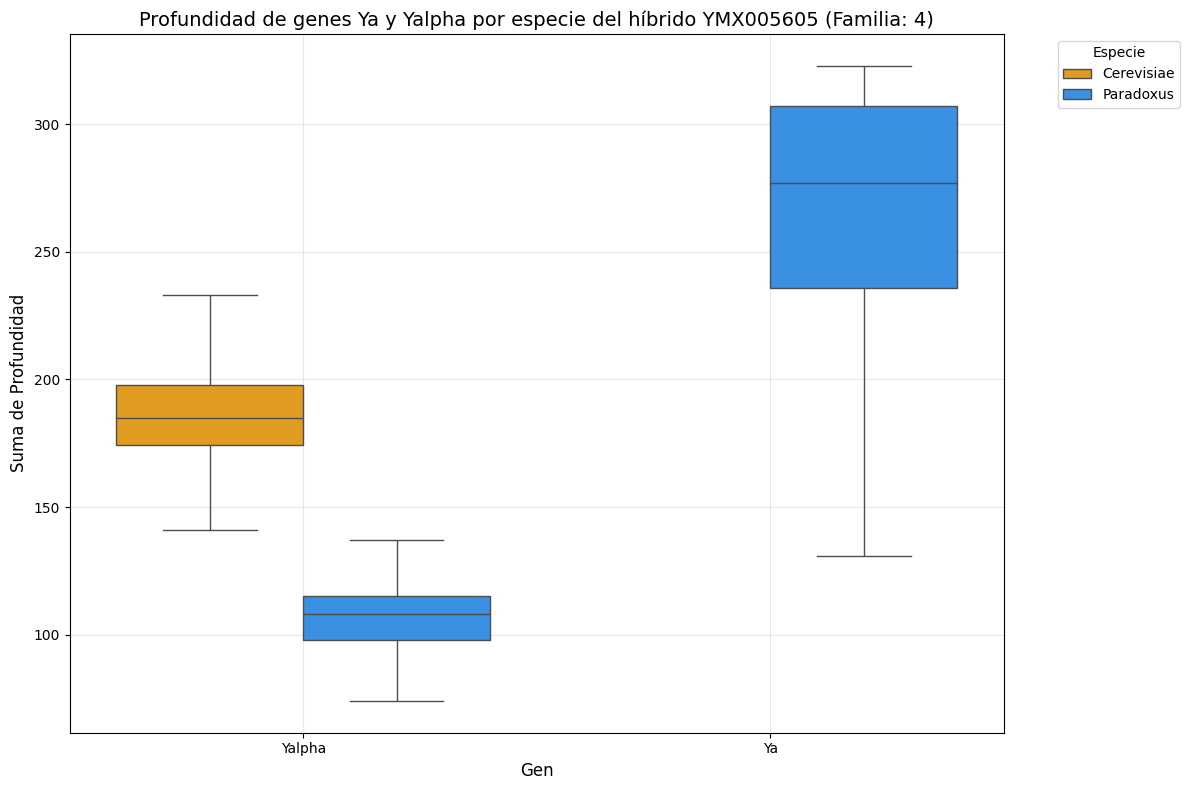

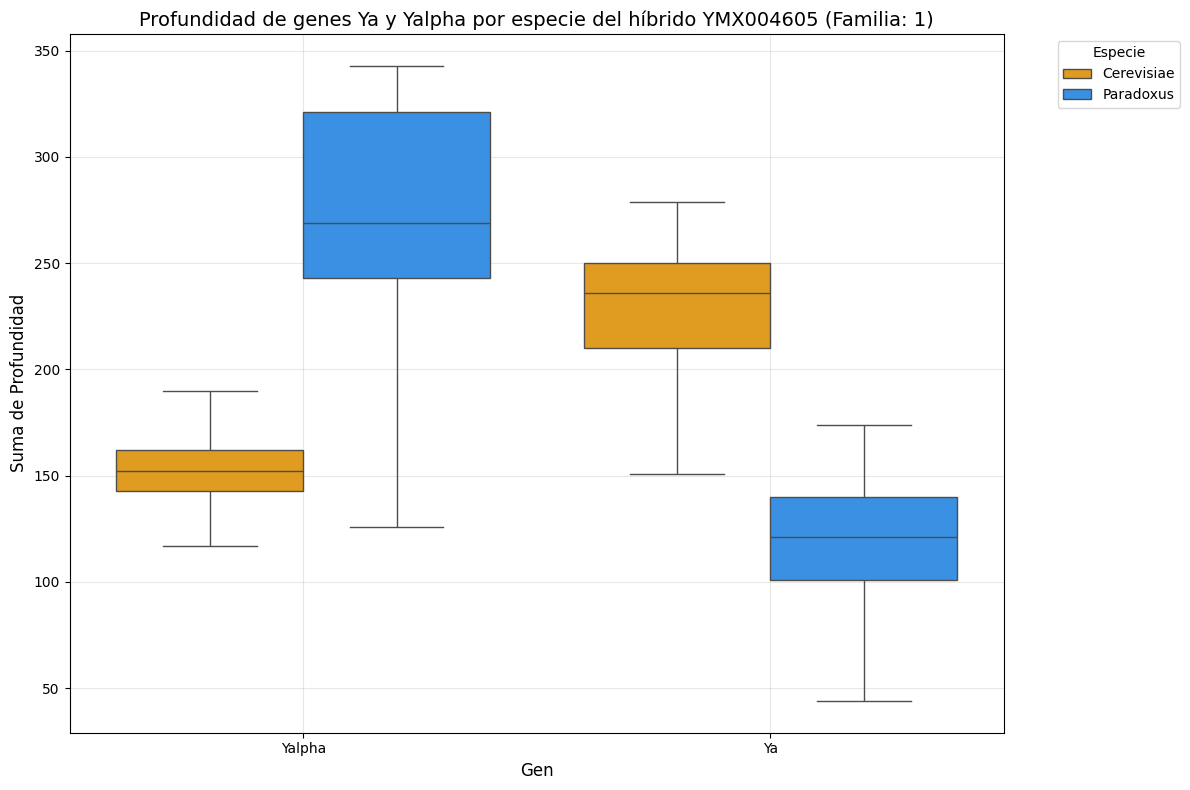

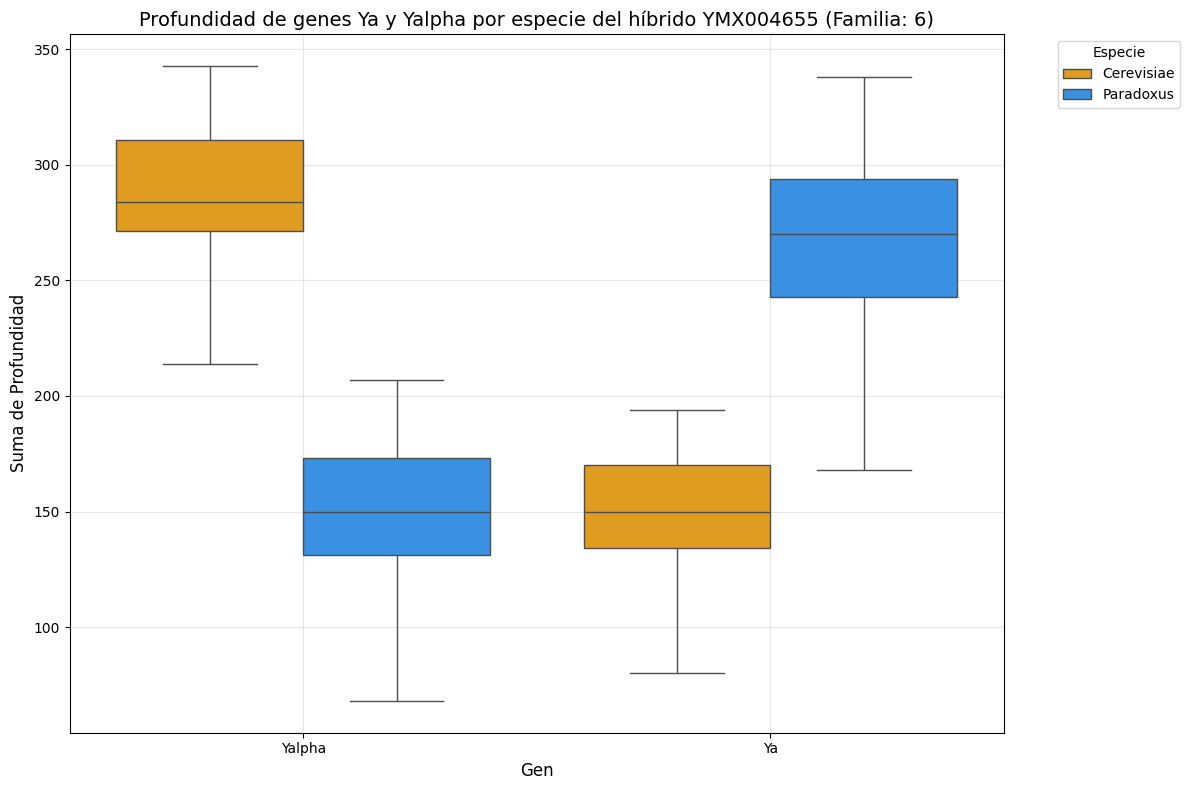

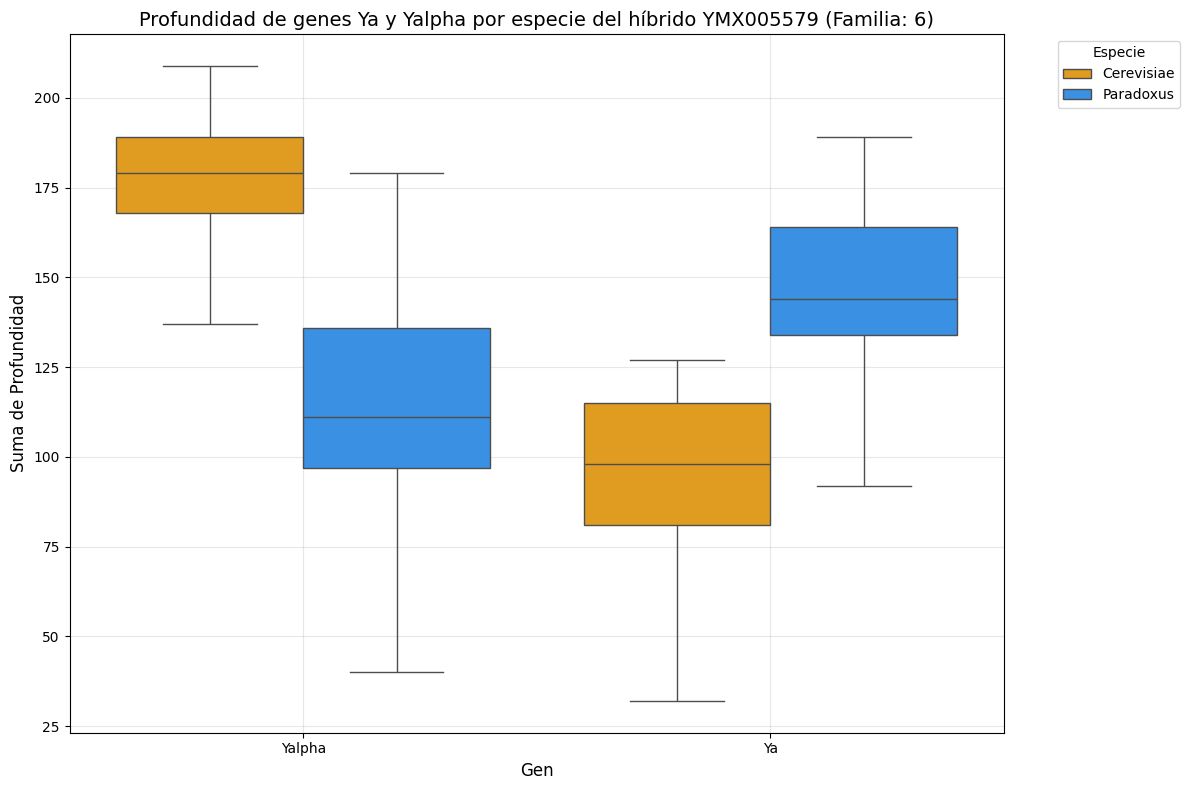

In [40]:
resultados = metodo_lociConcatenado(
    ruta_zip="/content/PROF_DIPLOIDES.zip",
    carpeta_destino="/content/PROF_DIPLOIDES",
    archivo_familias="/content/familias_hibridos.csv"
)

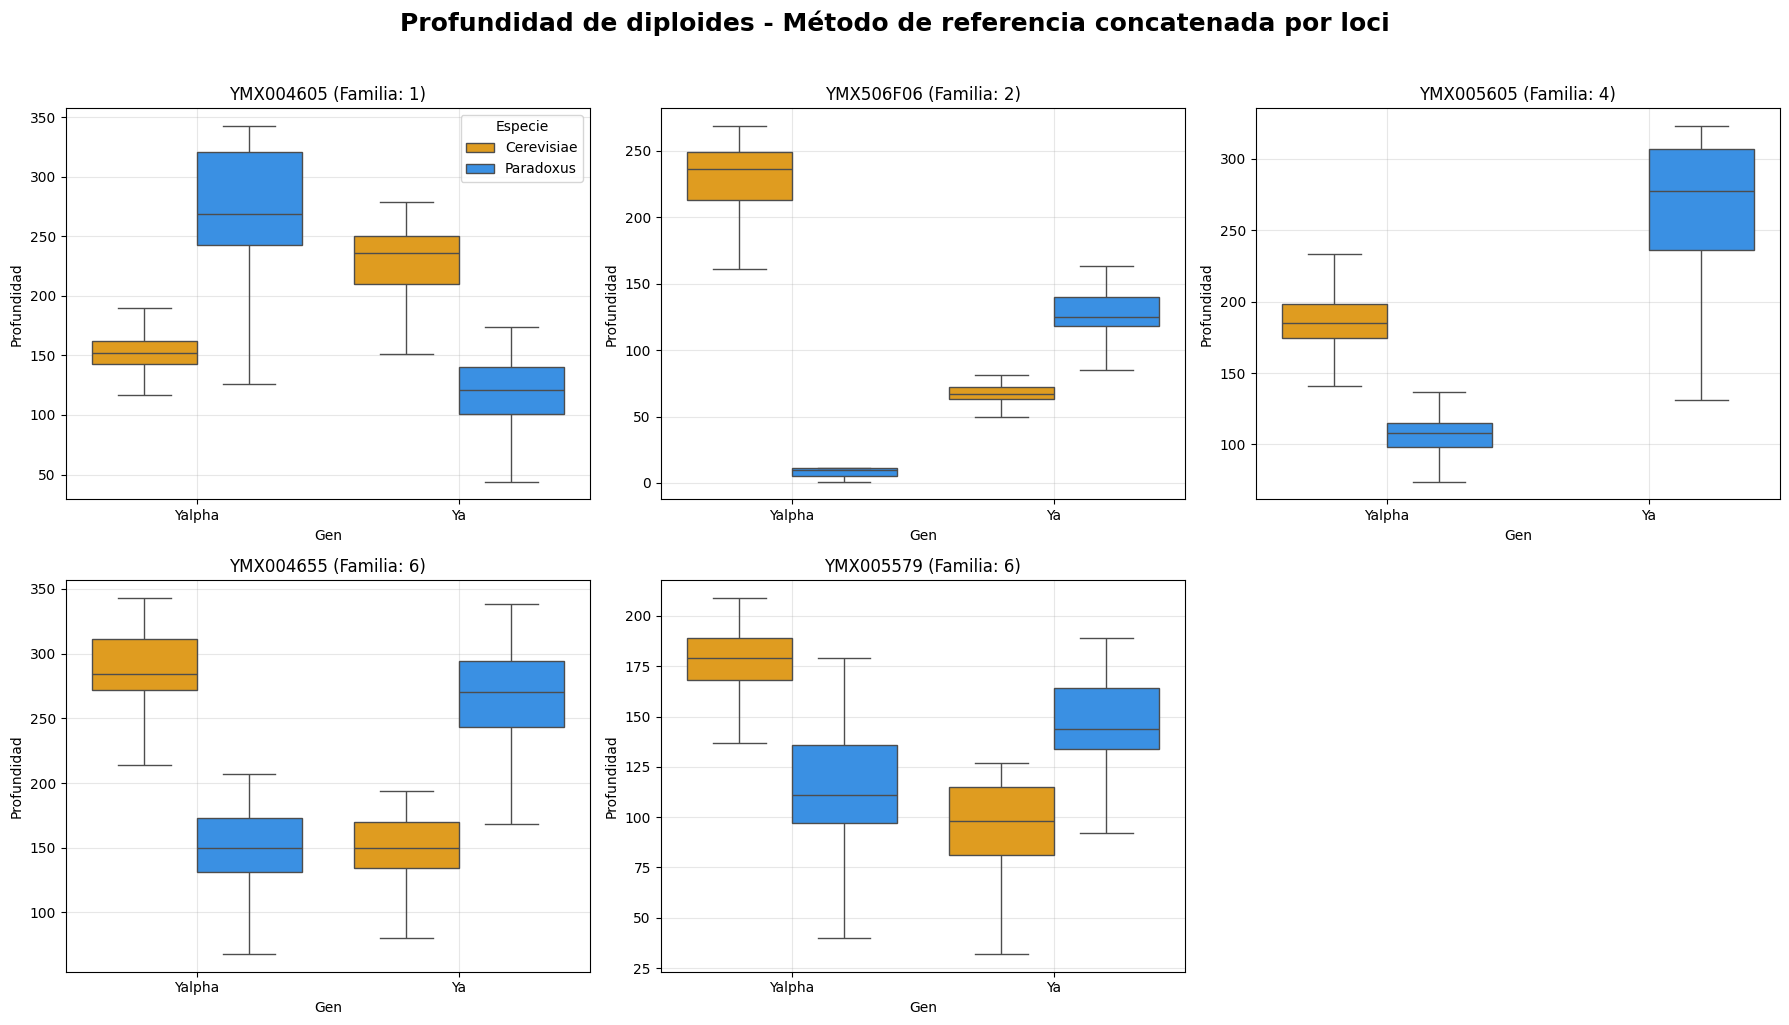

In [46]:
figura = generar_subplots(
    carpeta_tsv="/content/PROF_DIPLOIDES/PROF_DIPLOIDES/",
    archivo_familias="/content/familias_hibridos.csv"
)


## Triploides - Metodo 1: referencia concatenada por loci

Archive:  /content/PROF_TRIPLOIDES.zip
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_DK002c39.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_DK003c30.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_XA022c2.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_XA182c2.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_XA184c6.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_YMX004548.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_YMX004587.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_YMX004663.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_YMX004664.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_YMX004689.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_YMX004692.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/depth_YMX005536.tsv  
  inflating: /content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/dep

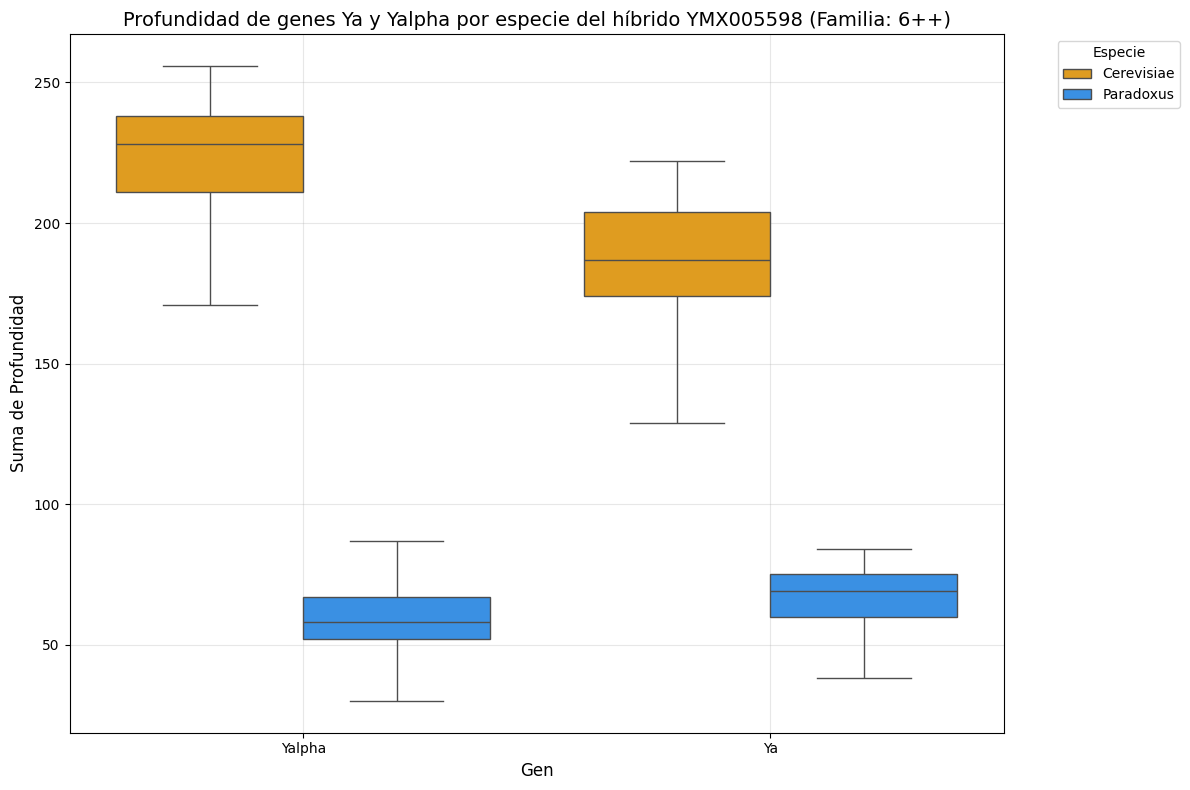

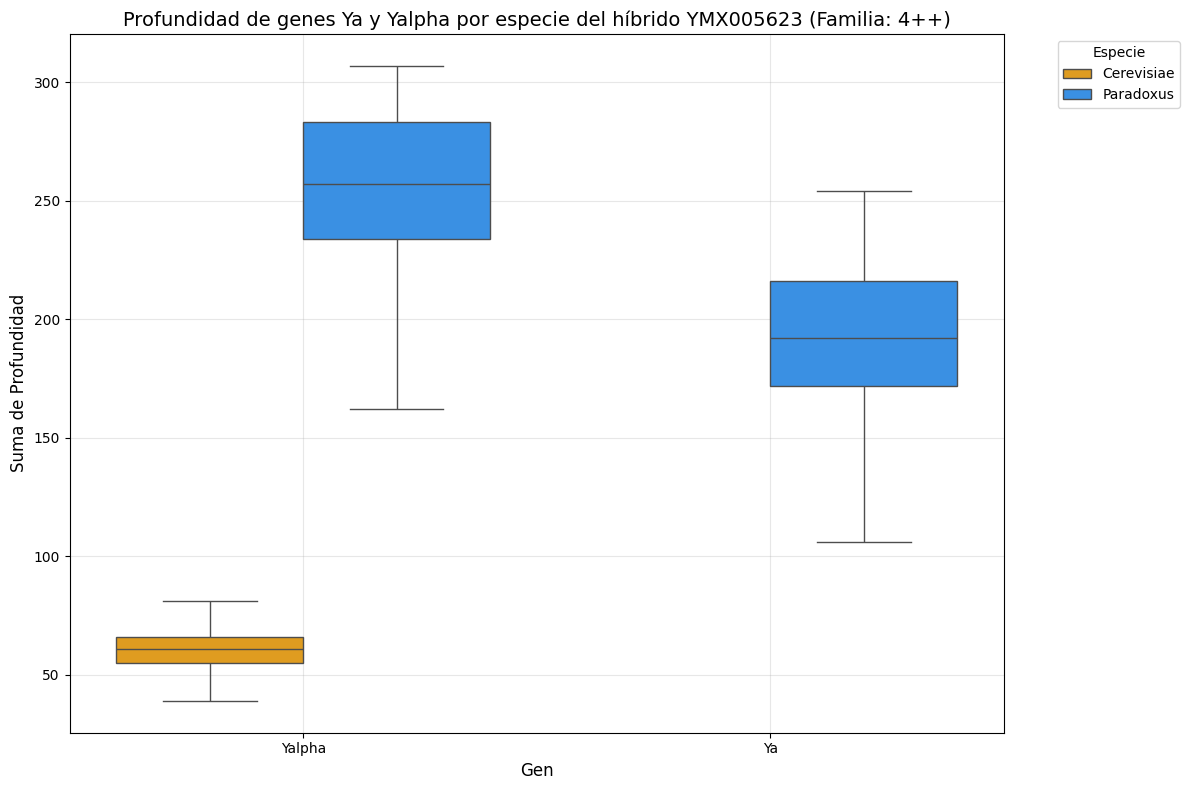

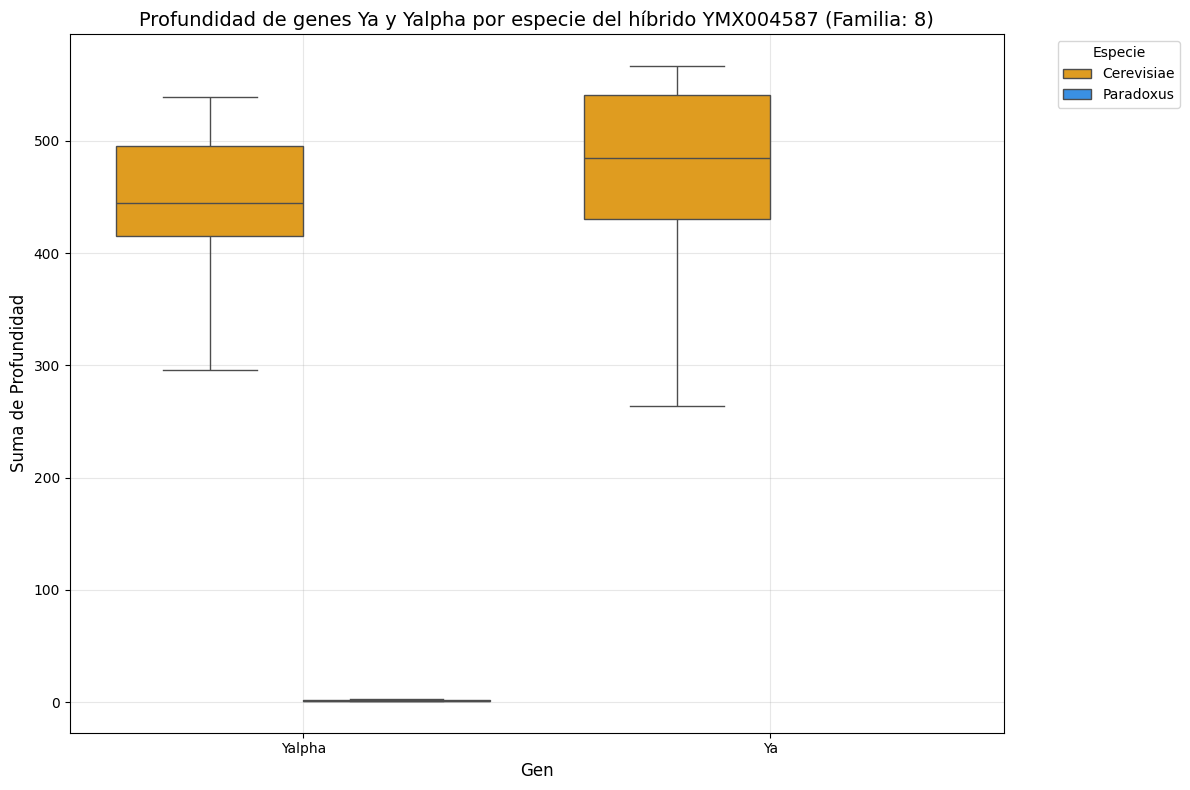

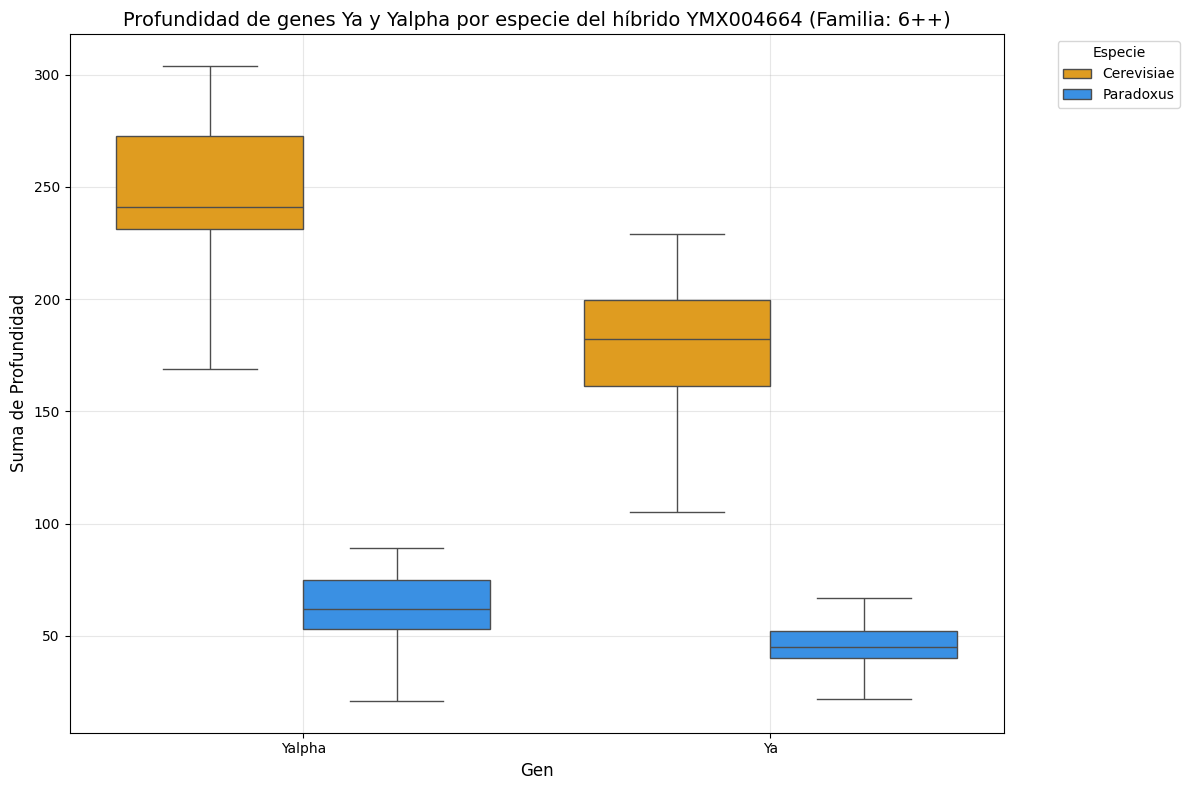

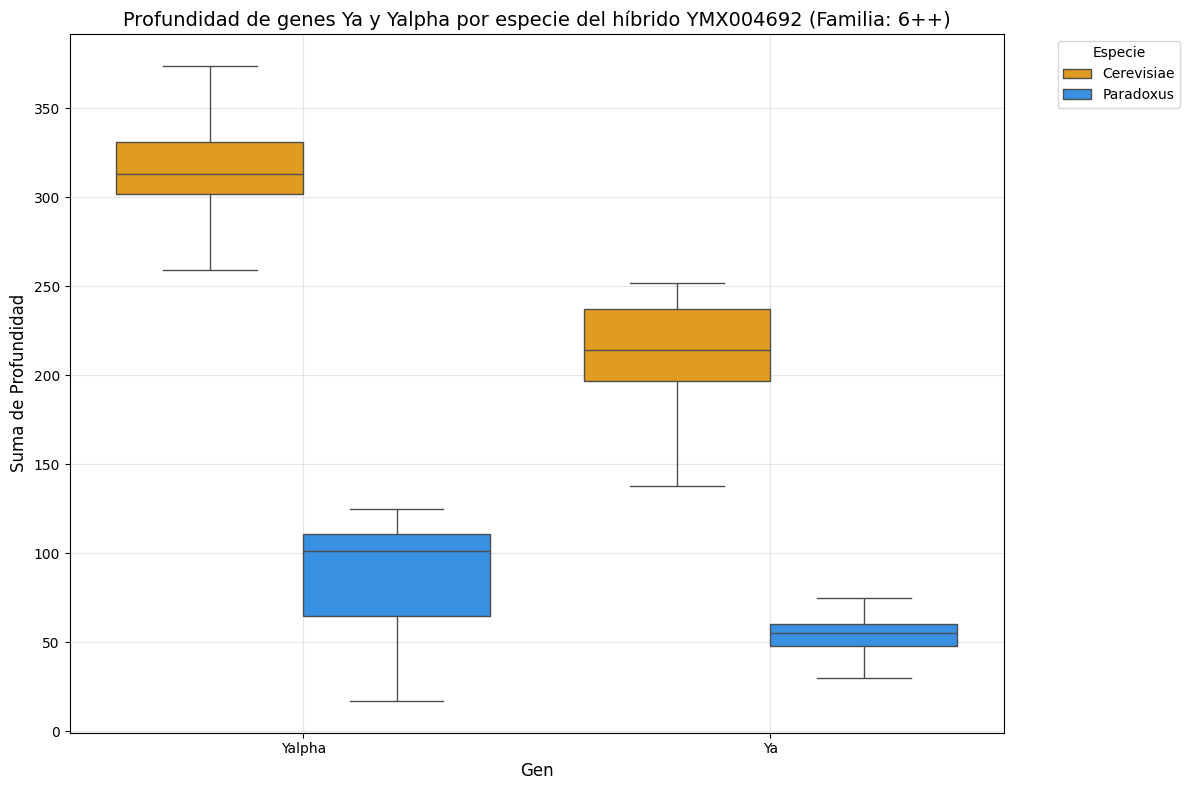

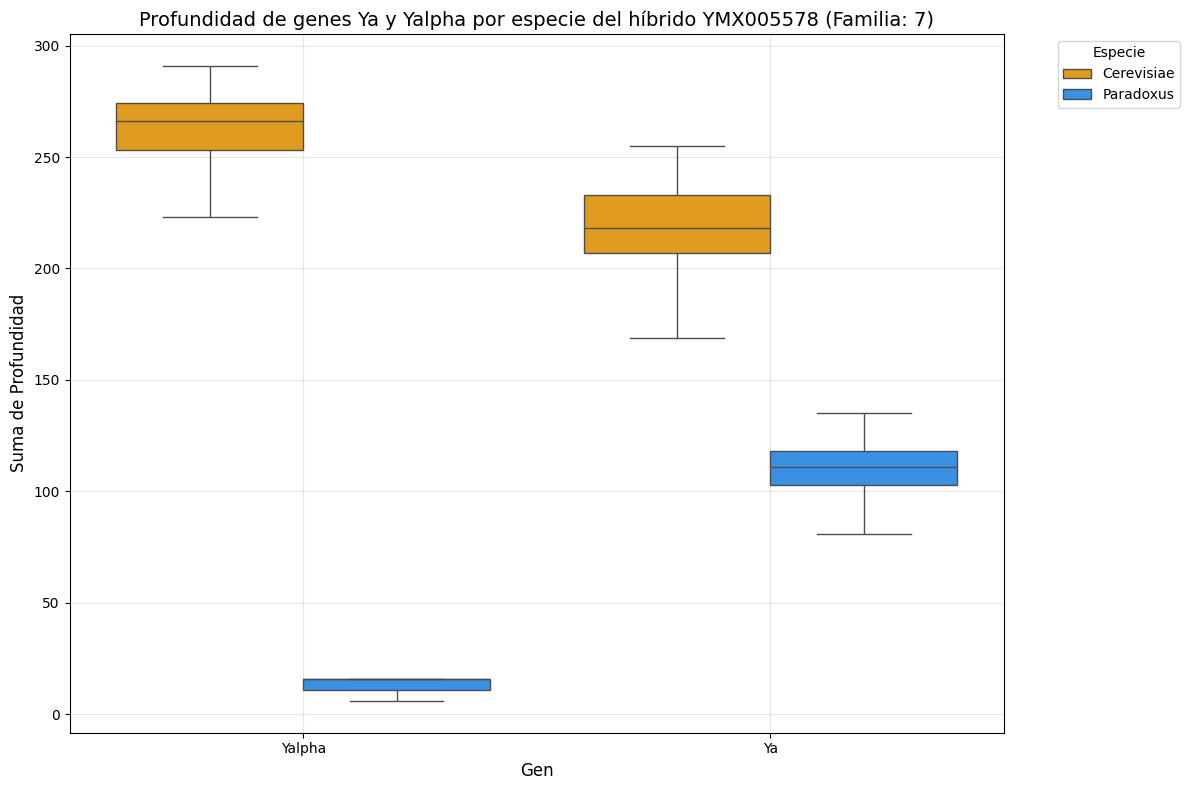

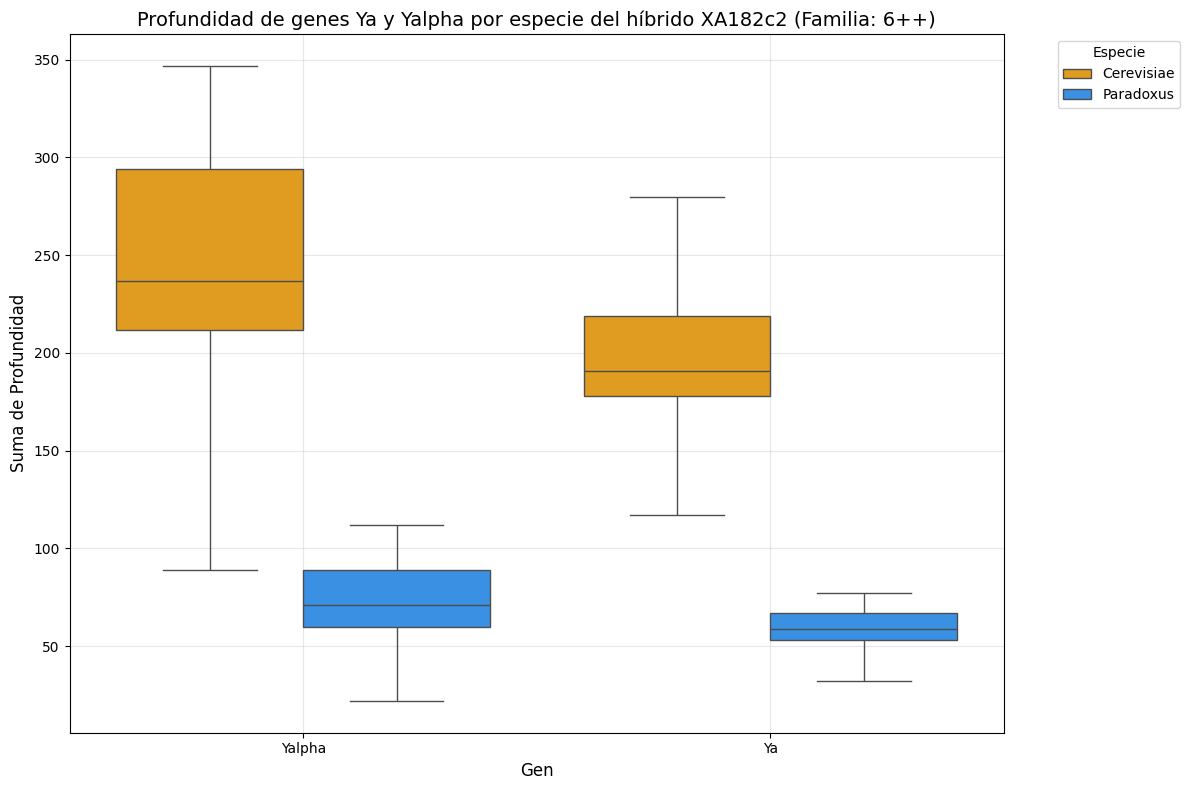

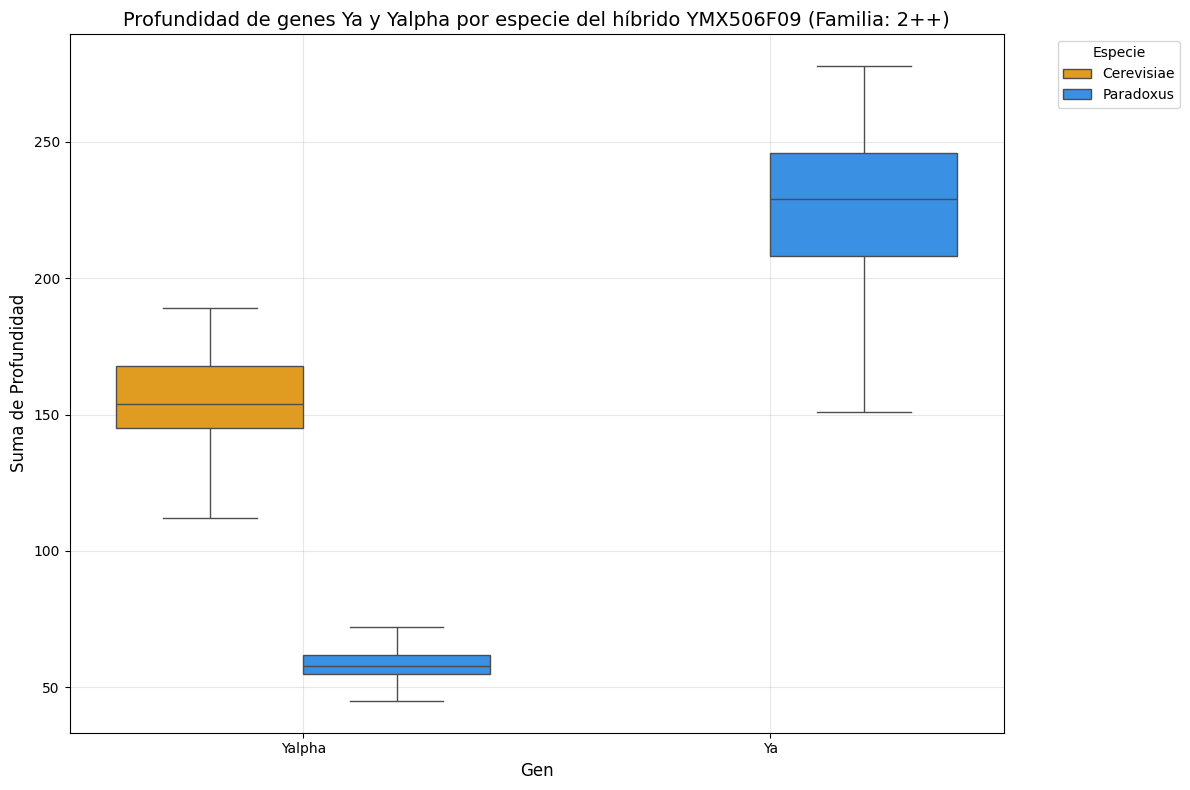

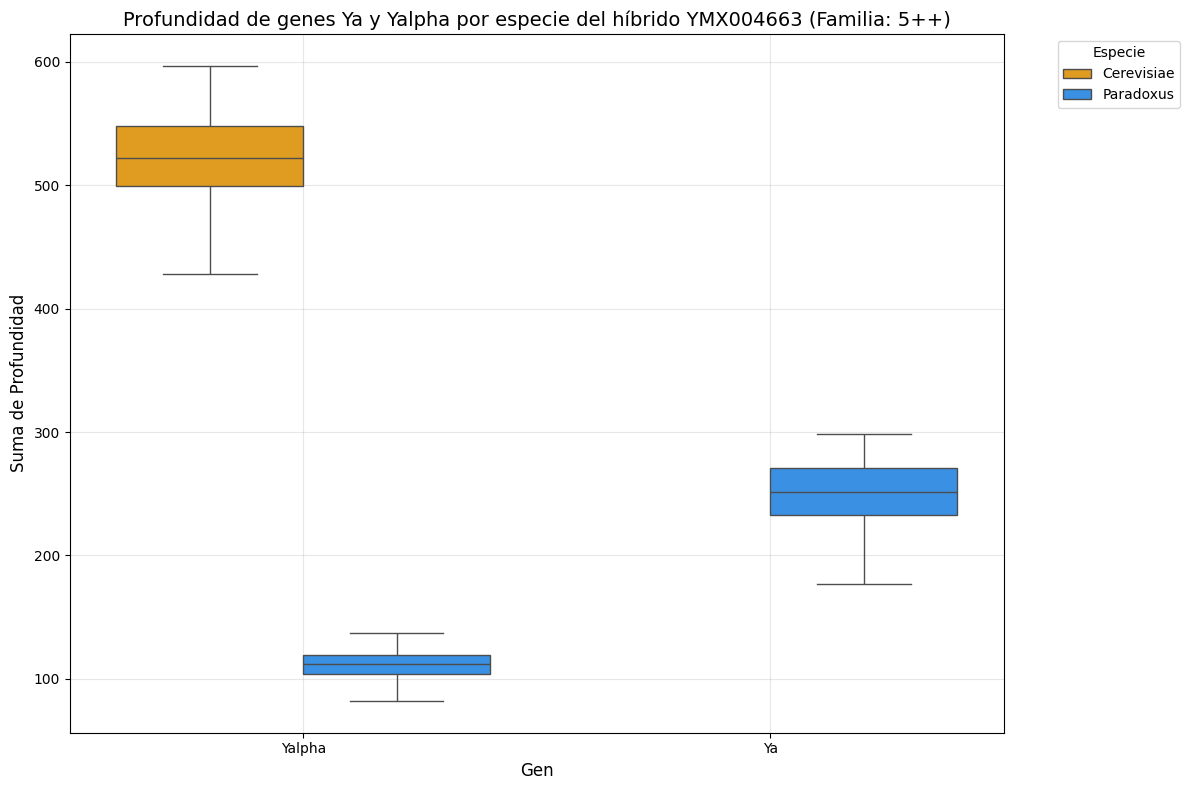

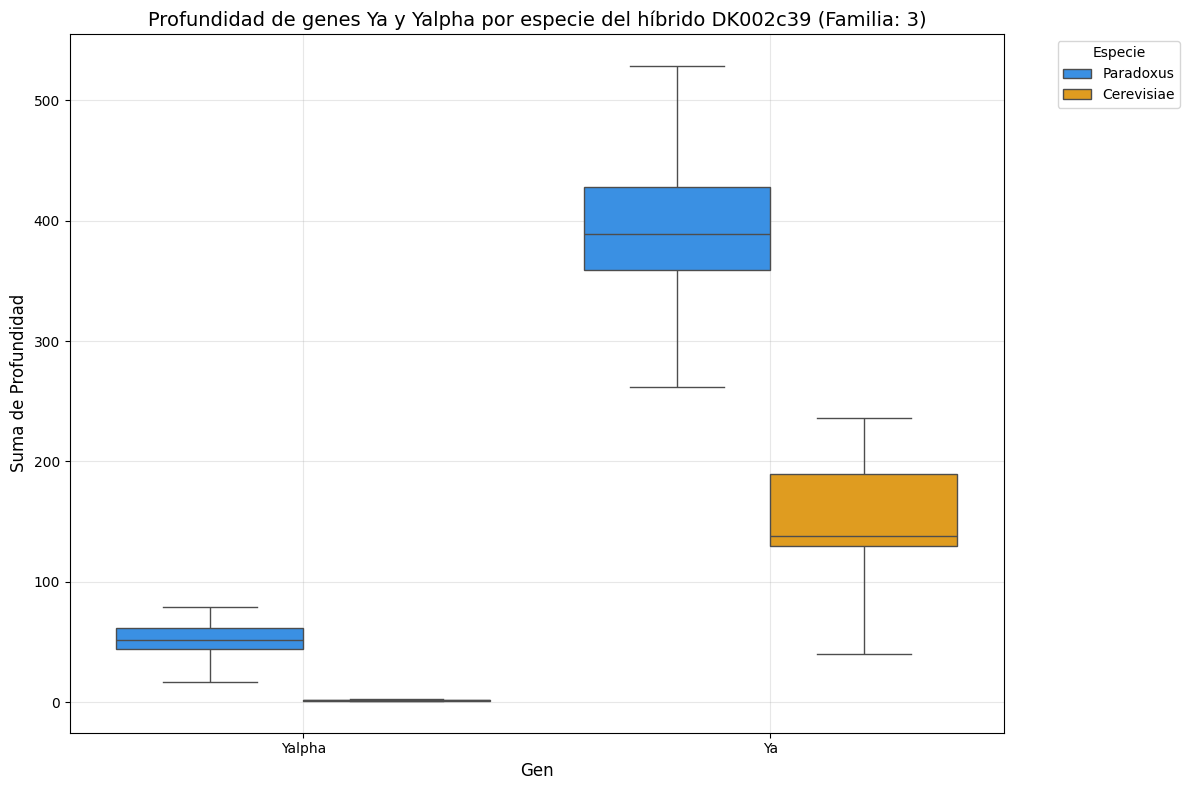

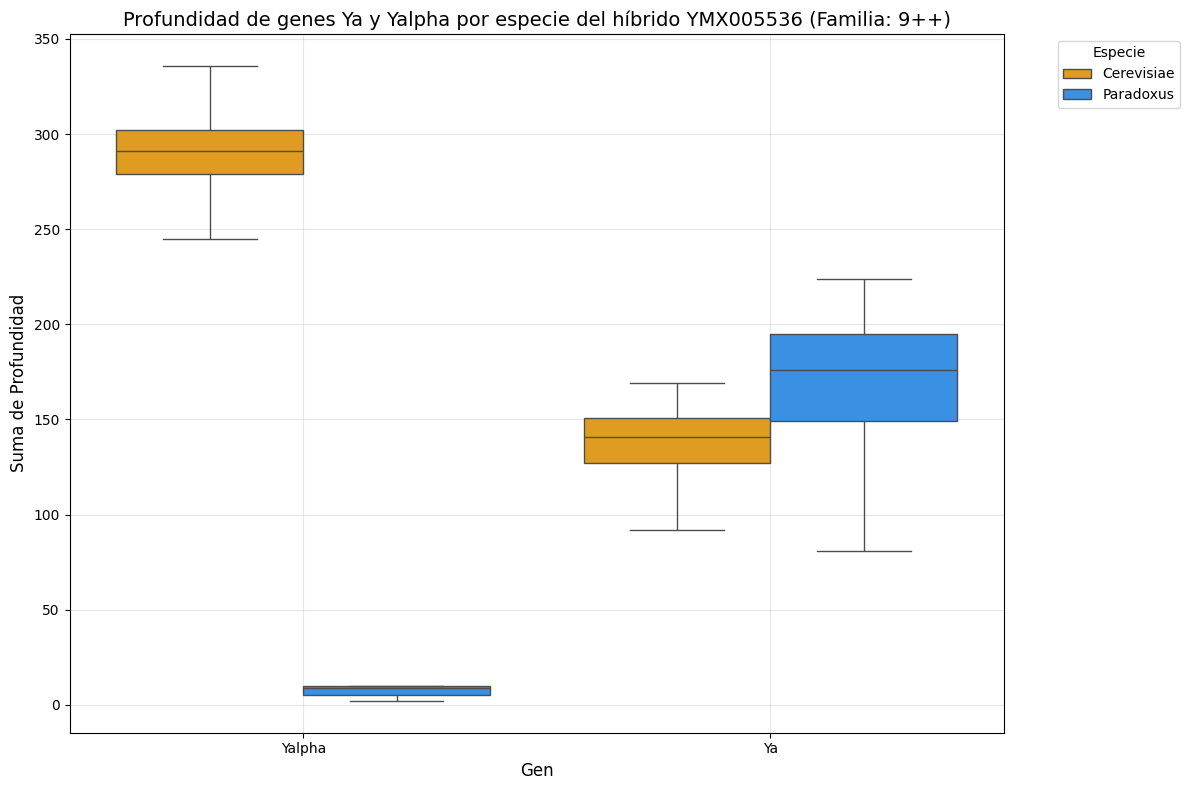

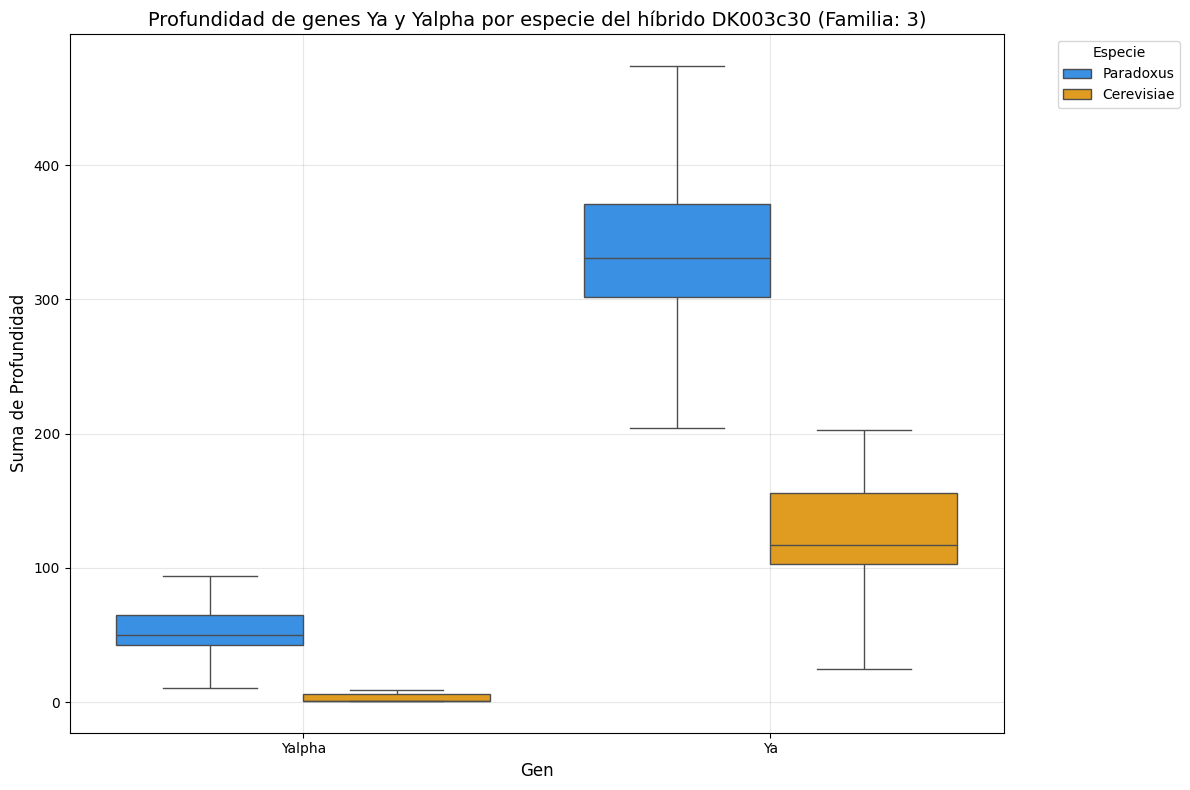

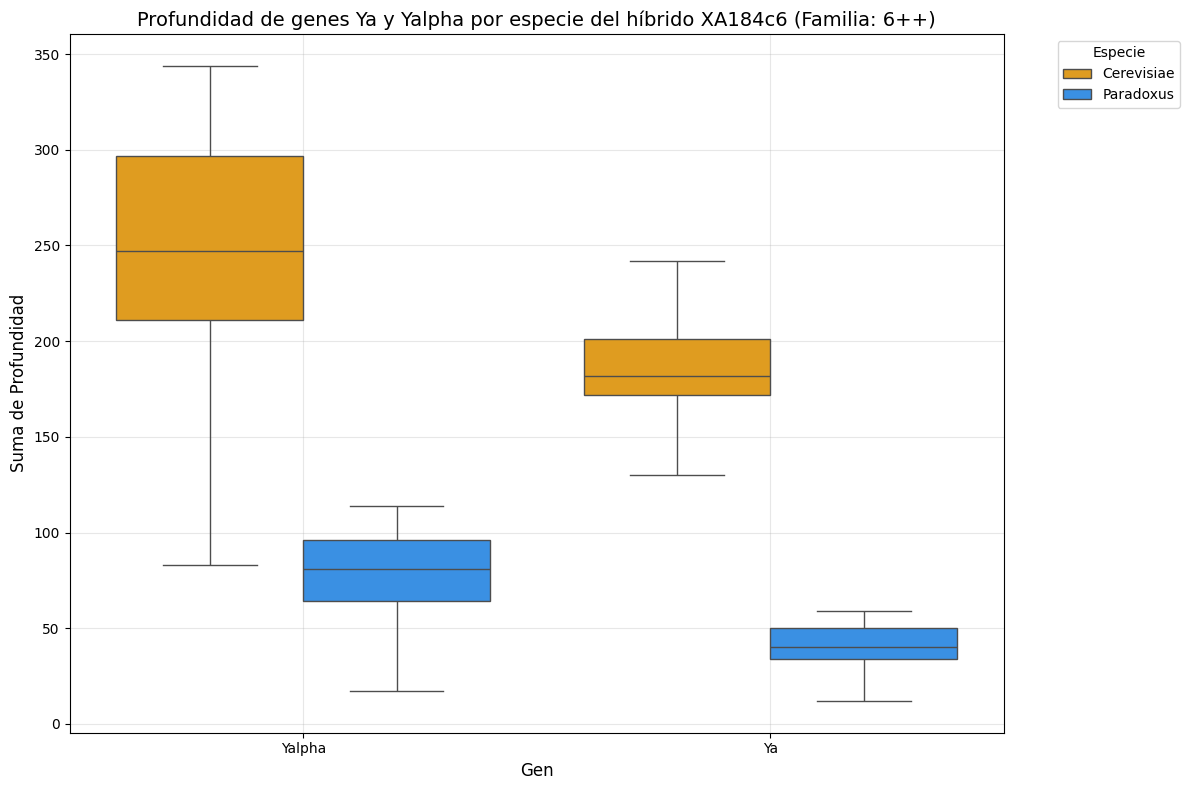

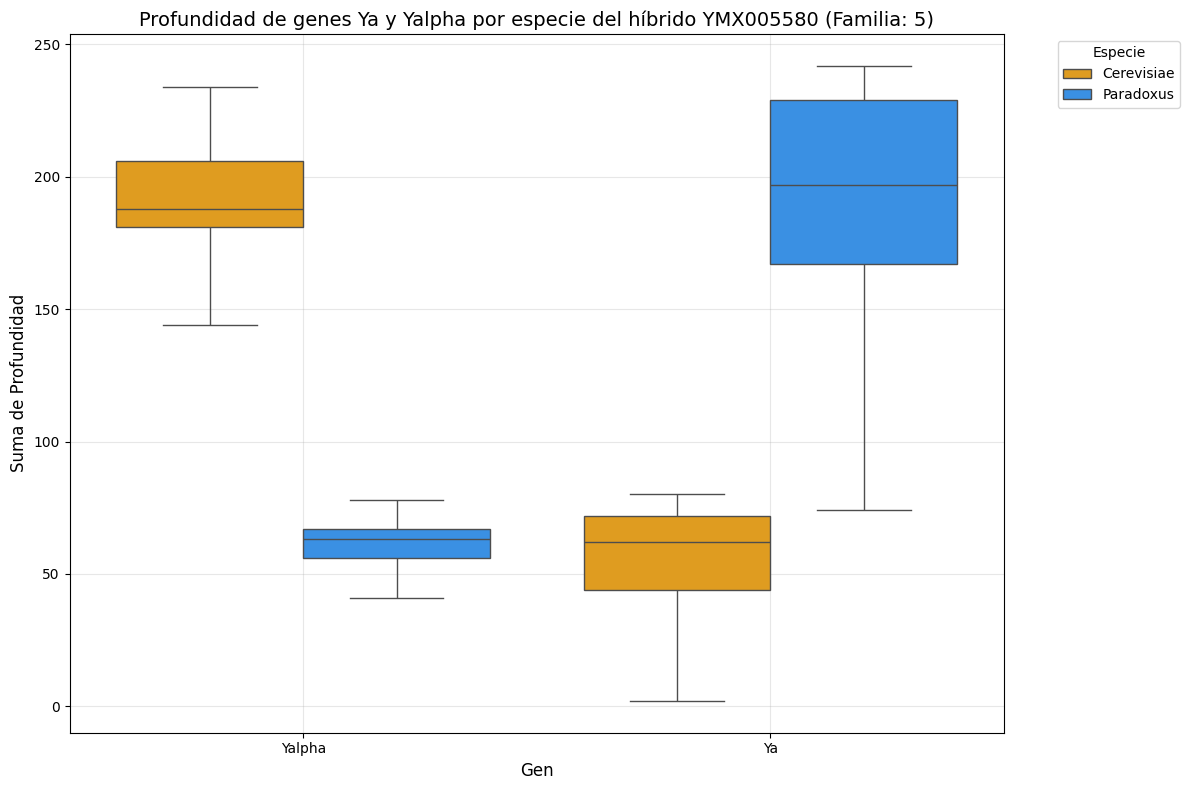

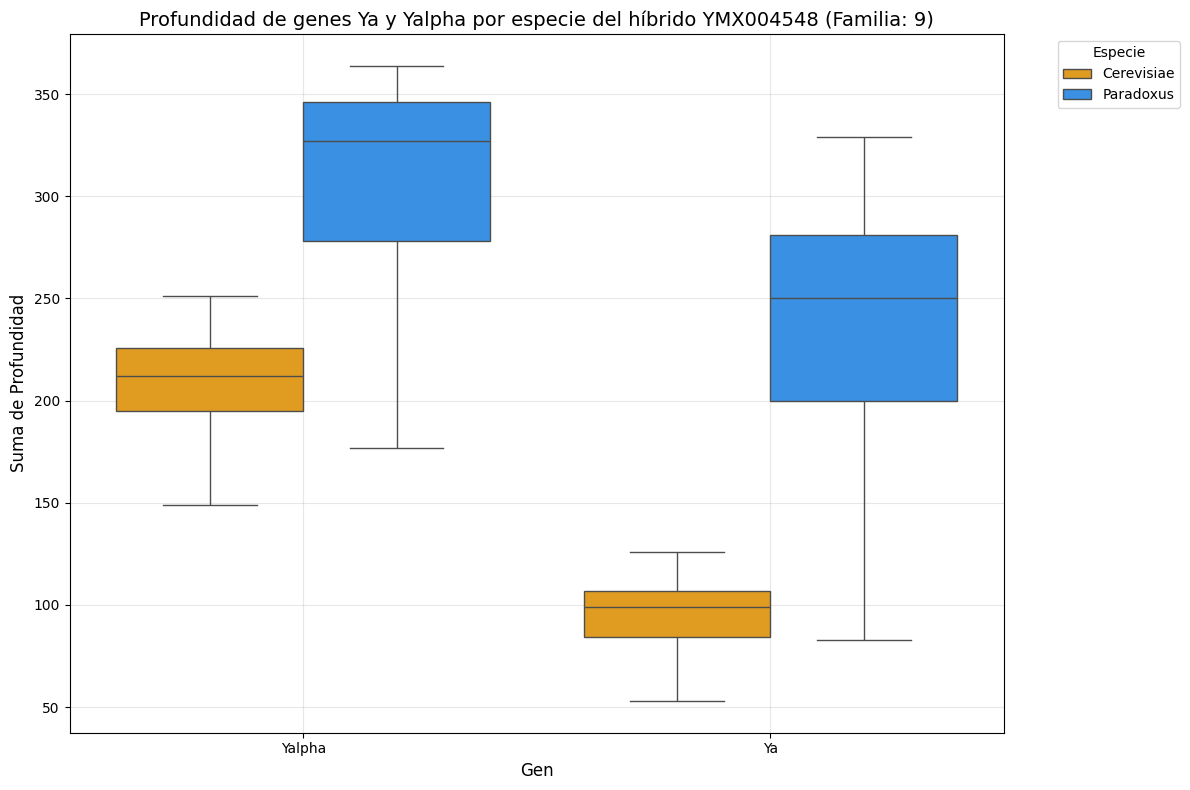

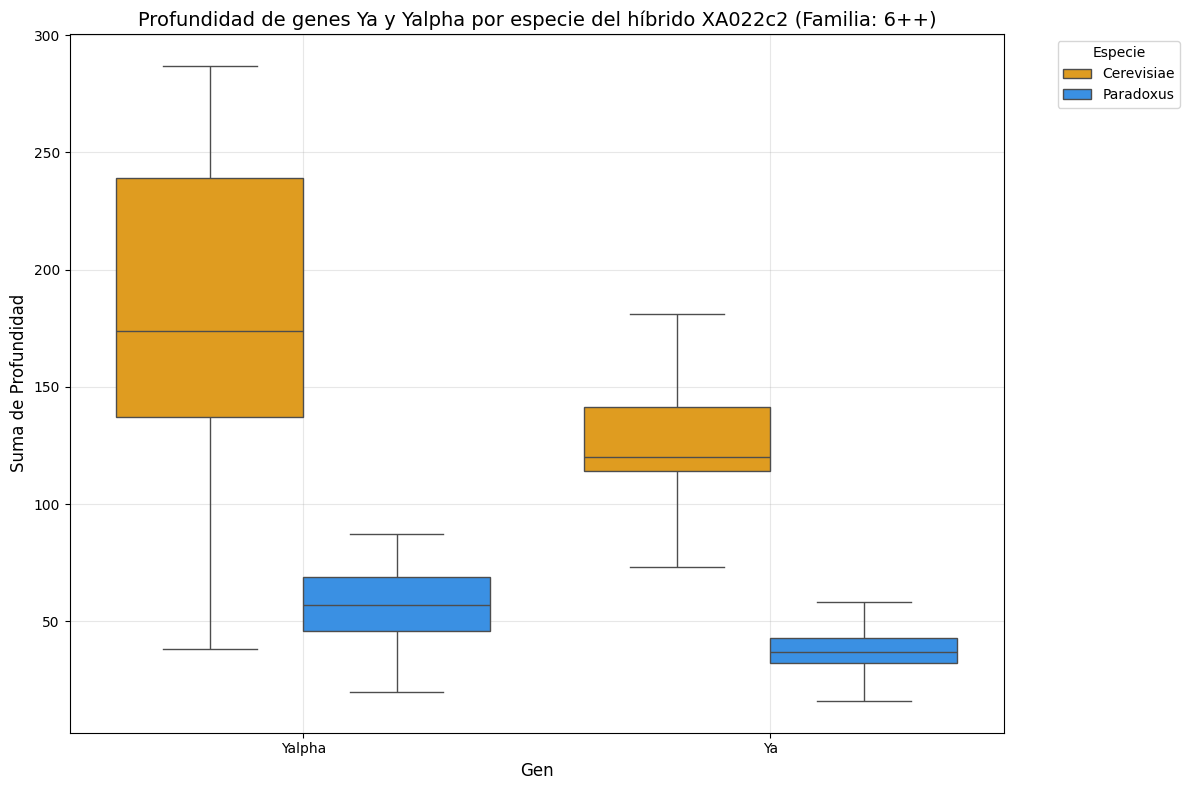

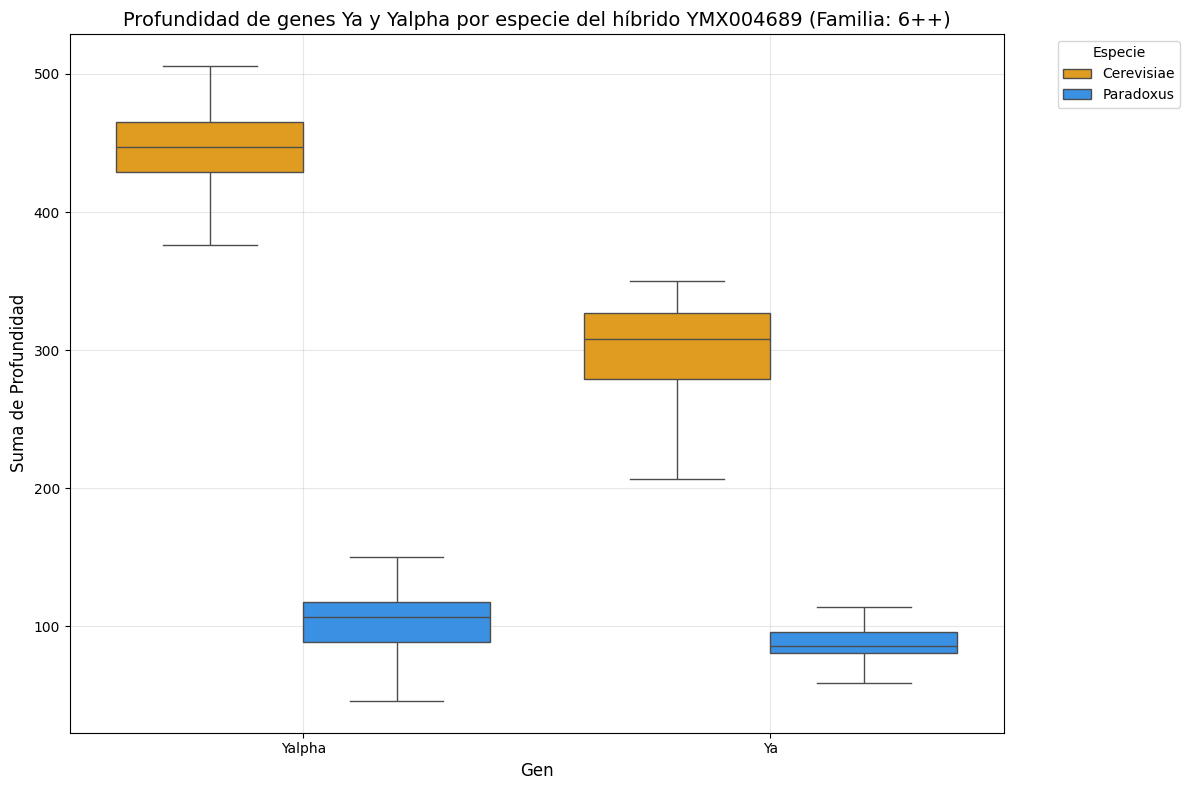

In [52]:
resultados = metodo_lociConcatenado(
    ruta_zip="/content/PROF_TRIPLOIDES.zip",
    carpeta_destino="/content/PROF_TRIPLOIDES",
    archivo_familias="/content/familias_hibridos.csv"
)

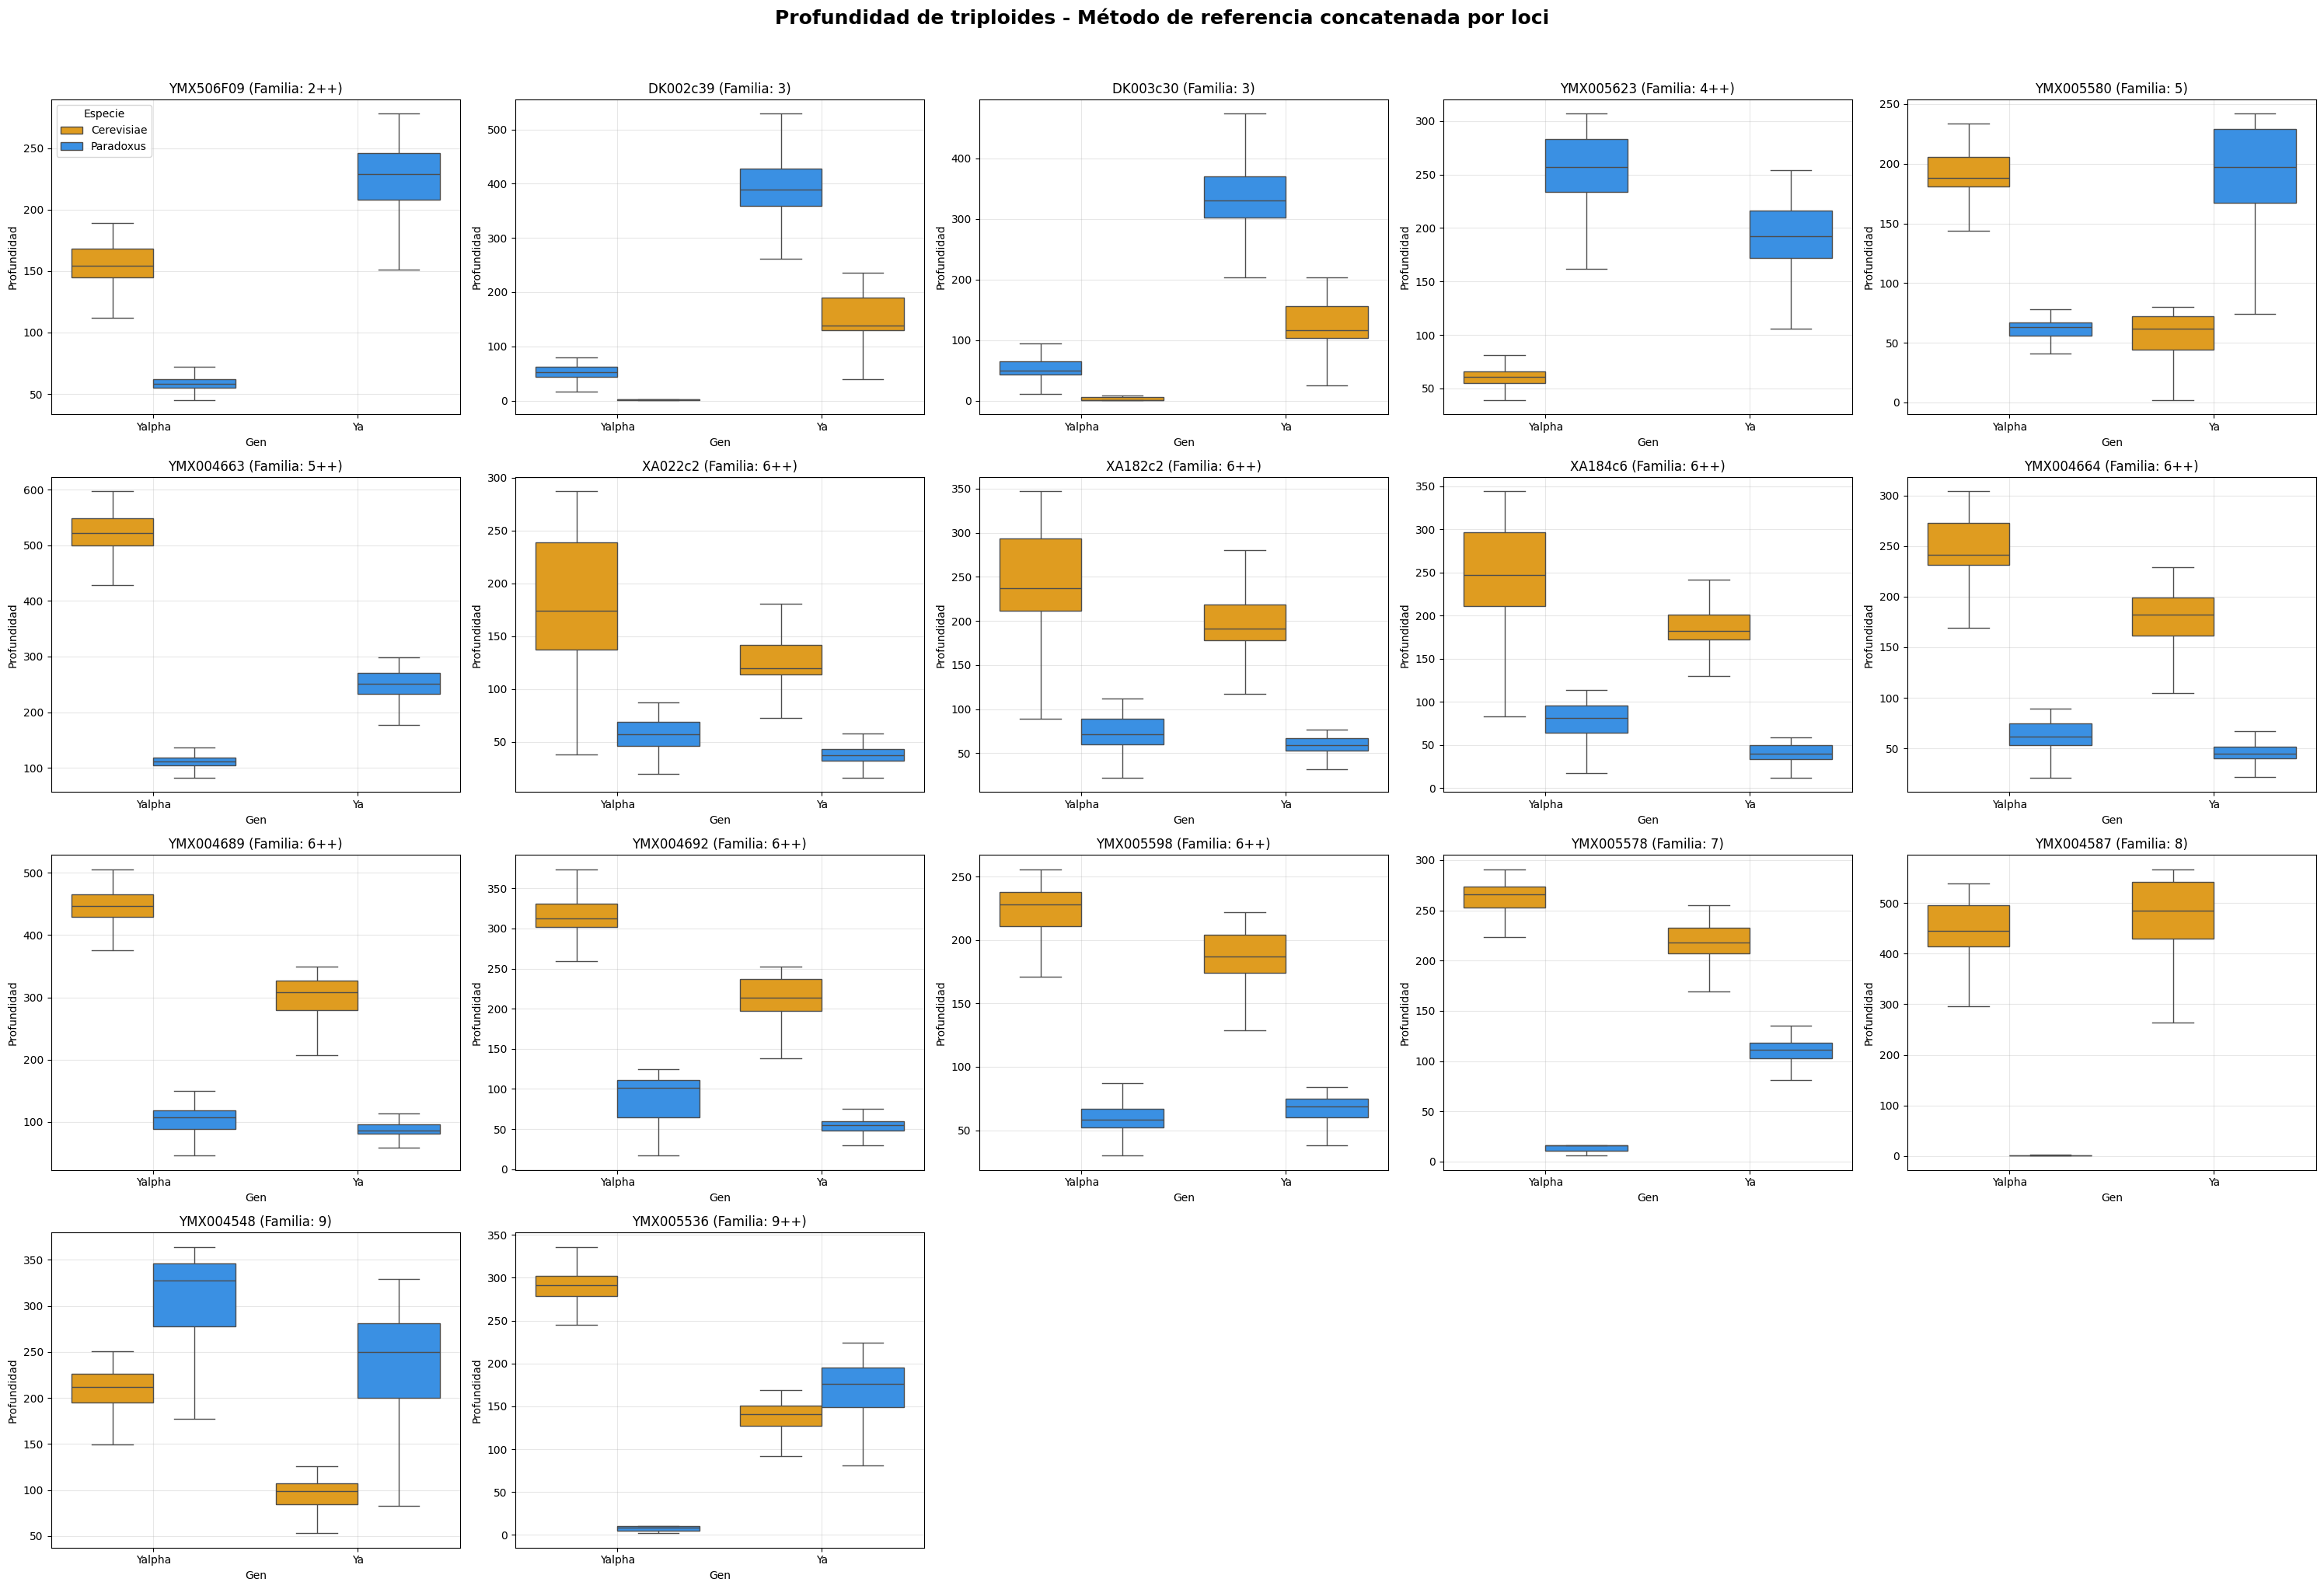

In [112]:
figura = generar_subplots(
    carpeta_tsv="/content/PROF_TRIPLOIDES/PROF_TRIPLOIDES/",
    archivo_familias="/content/familias_hibridos.csv"
)

# METODO 2 - REFERENCIA CONCATENADA POR CROMOSOMA

In [92]:
def plot_gen_Y(df, plot_title="Profundidad – Gen Y (S. cerevisiae / S. paradoxus)"):
    regiones_Y = {
        "Yα S. cerevisiae": [(12944, 13690), (200104, 200850)],
        "Yα S. paradoxus": [(14077, 14825), (194806, 195554)],
        "Ya S. cerevisiae": [(293737, 294378)],
        "Ya S. paradoxus": [(289137, 289773)]
    }

    colores = {
        "Yα S. cerevisiae": "orange",
        "Yα S. paradoxus": "blue",
        "Ya S. cerevisiae": "orange",
        "Ya S. paradoxus": "blue"
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    data = []
    labels = []
    colors = []

    for grupo, coords_list in regiones_Y.items():
        profundidades = []

        for (inicio, fin) in coords_list:
            df_filtro = df[df["posicion"].between(inicio, fin)]
            if not df_filtro.empty:
                profundidades.extend(df_filtro["profundidad"].values)

        if len(profundidades) > 0:
            data.append(profundidades)
            labels.append(grupo)
            colors.append(colores[grupo])

    bp = ax.boxplot(data, labels=labels, patch_artist=True)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(plot_title)
    ax.set_xlabel("Grupo del gen Y")
    ax.set_ylabel("Profundidad")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()

    return fig   # <<---- OBLIGATORIO


/tmp/ipython-input-1928543634.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


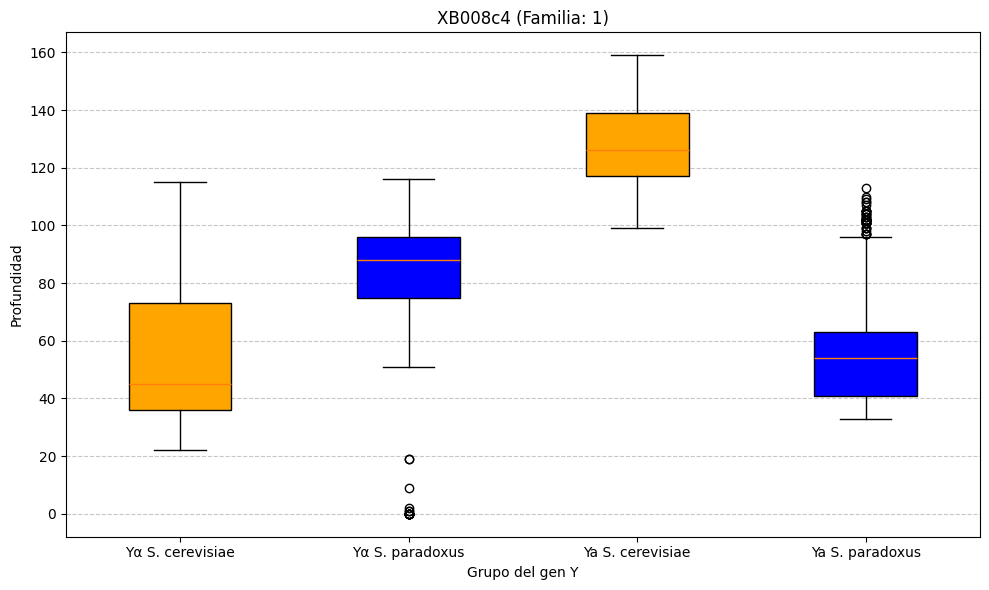

In [83]:
# Load familias_hibridos.csv to get family information
df_familias_m2 = pd.read_csv('/content/familias_hibridos.csv')
dic_familias_m2 = dict(zip(df_familias_m2["ID"], df_familias_m2["FAMILIA"]))

archivo_profundidad = '/content/depth/depth/XB008c4_CONC_filtrado.depth'
nombre_archivo = os.path.splitext(os.path.basename(archivo_profundidad))[0]
# Assuming hybrid ID is the part before '_CONC_filtrado'
hibrido_id = nombre_archivo.split('_')[0]

familia = dic_familias_m2.get(hibrido_id, "FAMILIA_DESCONOCIDA")
nombre_mostrar = f"{hibrido_id} (Familia: {familia})"

df_m2 = crear_df(archivo_profundidad)
plot_gen_Y(df_m2, plot_title=nombre_mostrar)

In [93]:
lista_hibridos_Dip_M2 = [
    "XB008c4", "YMX004605", "YMX004626", "YMX005562", "YMX506F06",
    "YMX506G01", "YMX506G07", "YMX507A08", "YMX005605", "XA192c4",
    "YMX004655", "YMX005579", "YMX506C05", "YMX506C06", "YMX506C08",
    "YMX506D05", "YMX506D06"
]


In [101]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def metodo_genY_lista(lista_ids, carpeta_depth, archivo_familias, carpeta_imagenes="imagenesM2"):
    """
    Procesa solo los archivos .depth cuyos IDs estén en lista_ids.
    Genera las gráficas del gen Y y las guarda en una carpeta.

    Parámetros:
        lista_ids: lista de IDs (ejemplo: ["XB008c4", "YMX004605"])
        carpeta_depth: carpeta donde están los archivos .depth
        archivo_familias: CSV con columnas ID y FAMILIA
        carpeta_imagenes: nombre de la carpeta donde guardar las figuras PNG

    Retorna:
        dict { ID : DataFrame } con los DataFrames procesados (no las figuras)
    """

    # --- 1) Crear carpeta de imágenes si no existe ---
    if not os.path.exists(carpeta_imagenes):
        os.makedirs(carpeta_imagenes)
        print(f"📁 Carpeta creada: {carpeta_imagenes}")
    else:
        print(f"📁 Carpeta ya existe: {carpeta_imagenes}")

    # --- 2) Cargar familias ---
    df_fam = pd.read_csv(archivo_familias)
    dic_familias = dict(zip(df_fam["ID"], df_fam["FAMILIA"]))

    resultados = {}

    # --- 3) Procesar archivos ---
    for hibrido in lista_ids:
        archivo = f"{hibrido}_CONC_filtrado.depth"
        ruta = os.path.join(carpeta_depth, archivo)

        if not os.path.exists(ruta):
            print(f"⚠️ Archivo NO encontrado: {archivo}")
            resultados[hibrido] = None
            continue

        print(f"📄 Procesando: {archivo}")

        # Familia
        familia = dic_familias.get(hibrido, "FAMILIA_DESCONOCIDA")

        # Cargar profundidad
        df = crear_df(ruta)

        # Título mostrado en la figura
        titulo = f"{hibrido} (Familia: {familia})"

        # Generar figura del gen Y (para guardar individualmente)
        fig = plot_gen_Y(df, plot_title=titulo)

        # --- 4) Guardar figura ---
        ruta_png = os.path.join(carpeta_imagenes, f"{hibrido}_genY.png")
        fig.savefig(ruta_png, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"✅ Guardado: {ruta_png}")

        # Almacenar el DataFrame procesado en lugar de la figura
        resultados[hibrido] = df

    return resultados

In [95]:


resultados = metodo_genY_lista(
    lista_ids=lista_hibridos_Dip_M2,
    carpeta_depth="/content/depth/depth/",
    archivo_familias="/content/familias_hibridos.csv",
    carpeta_imagenes="imagenesM2"
)



📁 Carpeta ya existe: imagenesM2
📄 Procesando: XB008c4_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2/XB008c4_genY.png
📄 Procesando: YMX004605_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2/YMX004605_genY.png
📄 Procesando: YMX004626_CONC_filtrado.depth


...

✅ Guardado: imagenesM2/YMX506C08_genY.png
📄 Procesando: YMX506D05_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2/YMX506D05_genY.png
📄 Procesando: YMX506D06_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2/YMX506D06_genY.png


In [105]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def subplot_desde_png(carpeta_imagenes, lista_ids, titulo="Subplot GenY - Todos los híbridos"):
    """
    Crea un subplot leyendo las imágenes PNG generadas previamente.
    """

    # Lista de rutas completas
    imagenes = [os.path.join(carpeta_imagenes, f"{h}_genY.png") for h in lista_ids]

    n = len(imagenes)
    cols = 4
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(22, 5*rows))
    axs = axs.flatten()

    for i, img_path in enumerate(imagenes):
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axs[i].imshow(img)
            axs[i].axis("off")
            axs[i].set_title(lista_ids[i])
        else:
            axs[i].text(0.5, 0.5, "NO ENCONTRADA", ha="center", va="center", fontsize=14)
            axs[i].axis("off")

    # Quitar ejes de subplots vacíos
    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    fig.suptitle(titulo, fontsize=18)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    return fig


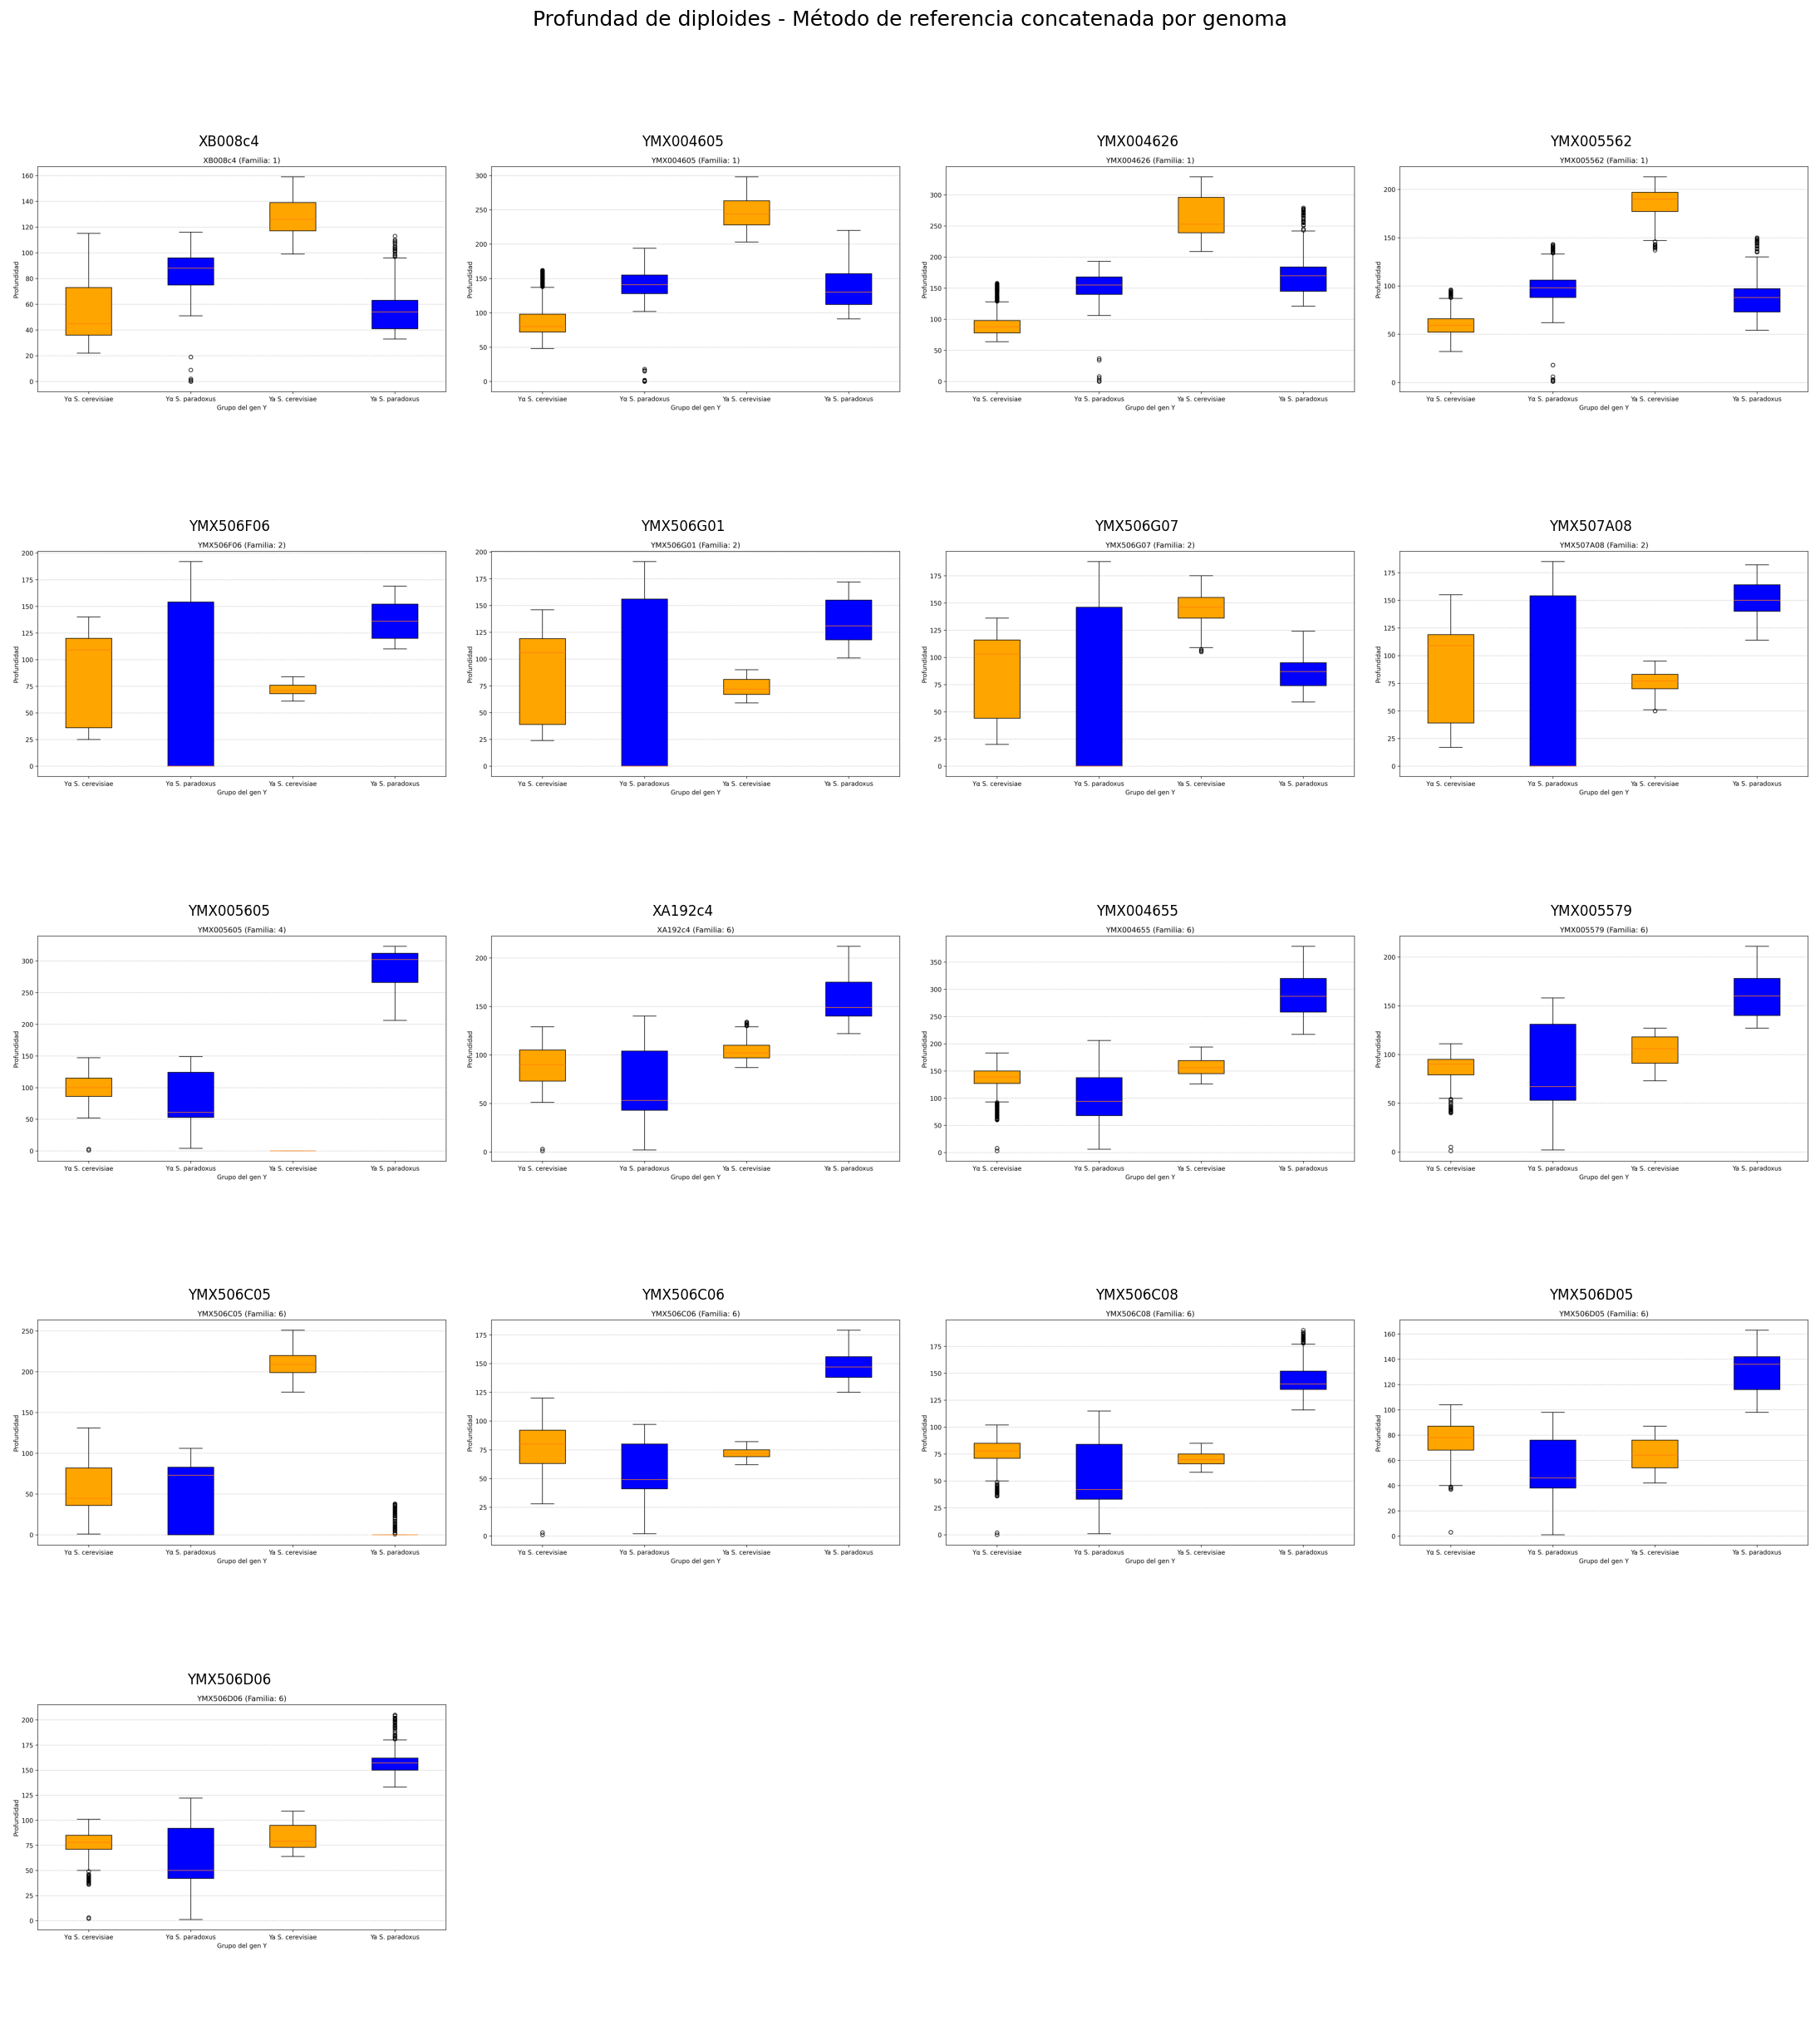

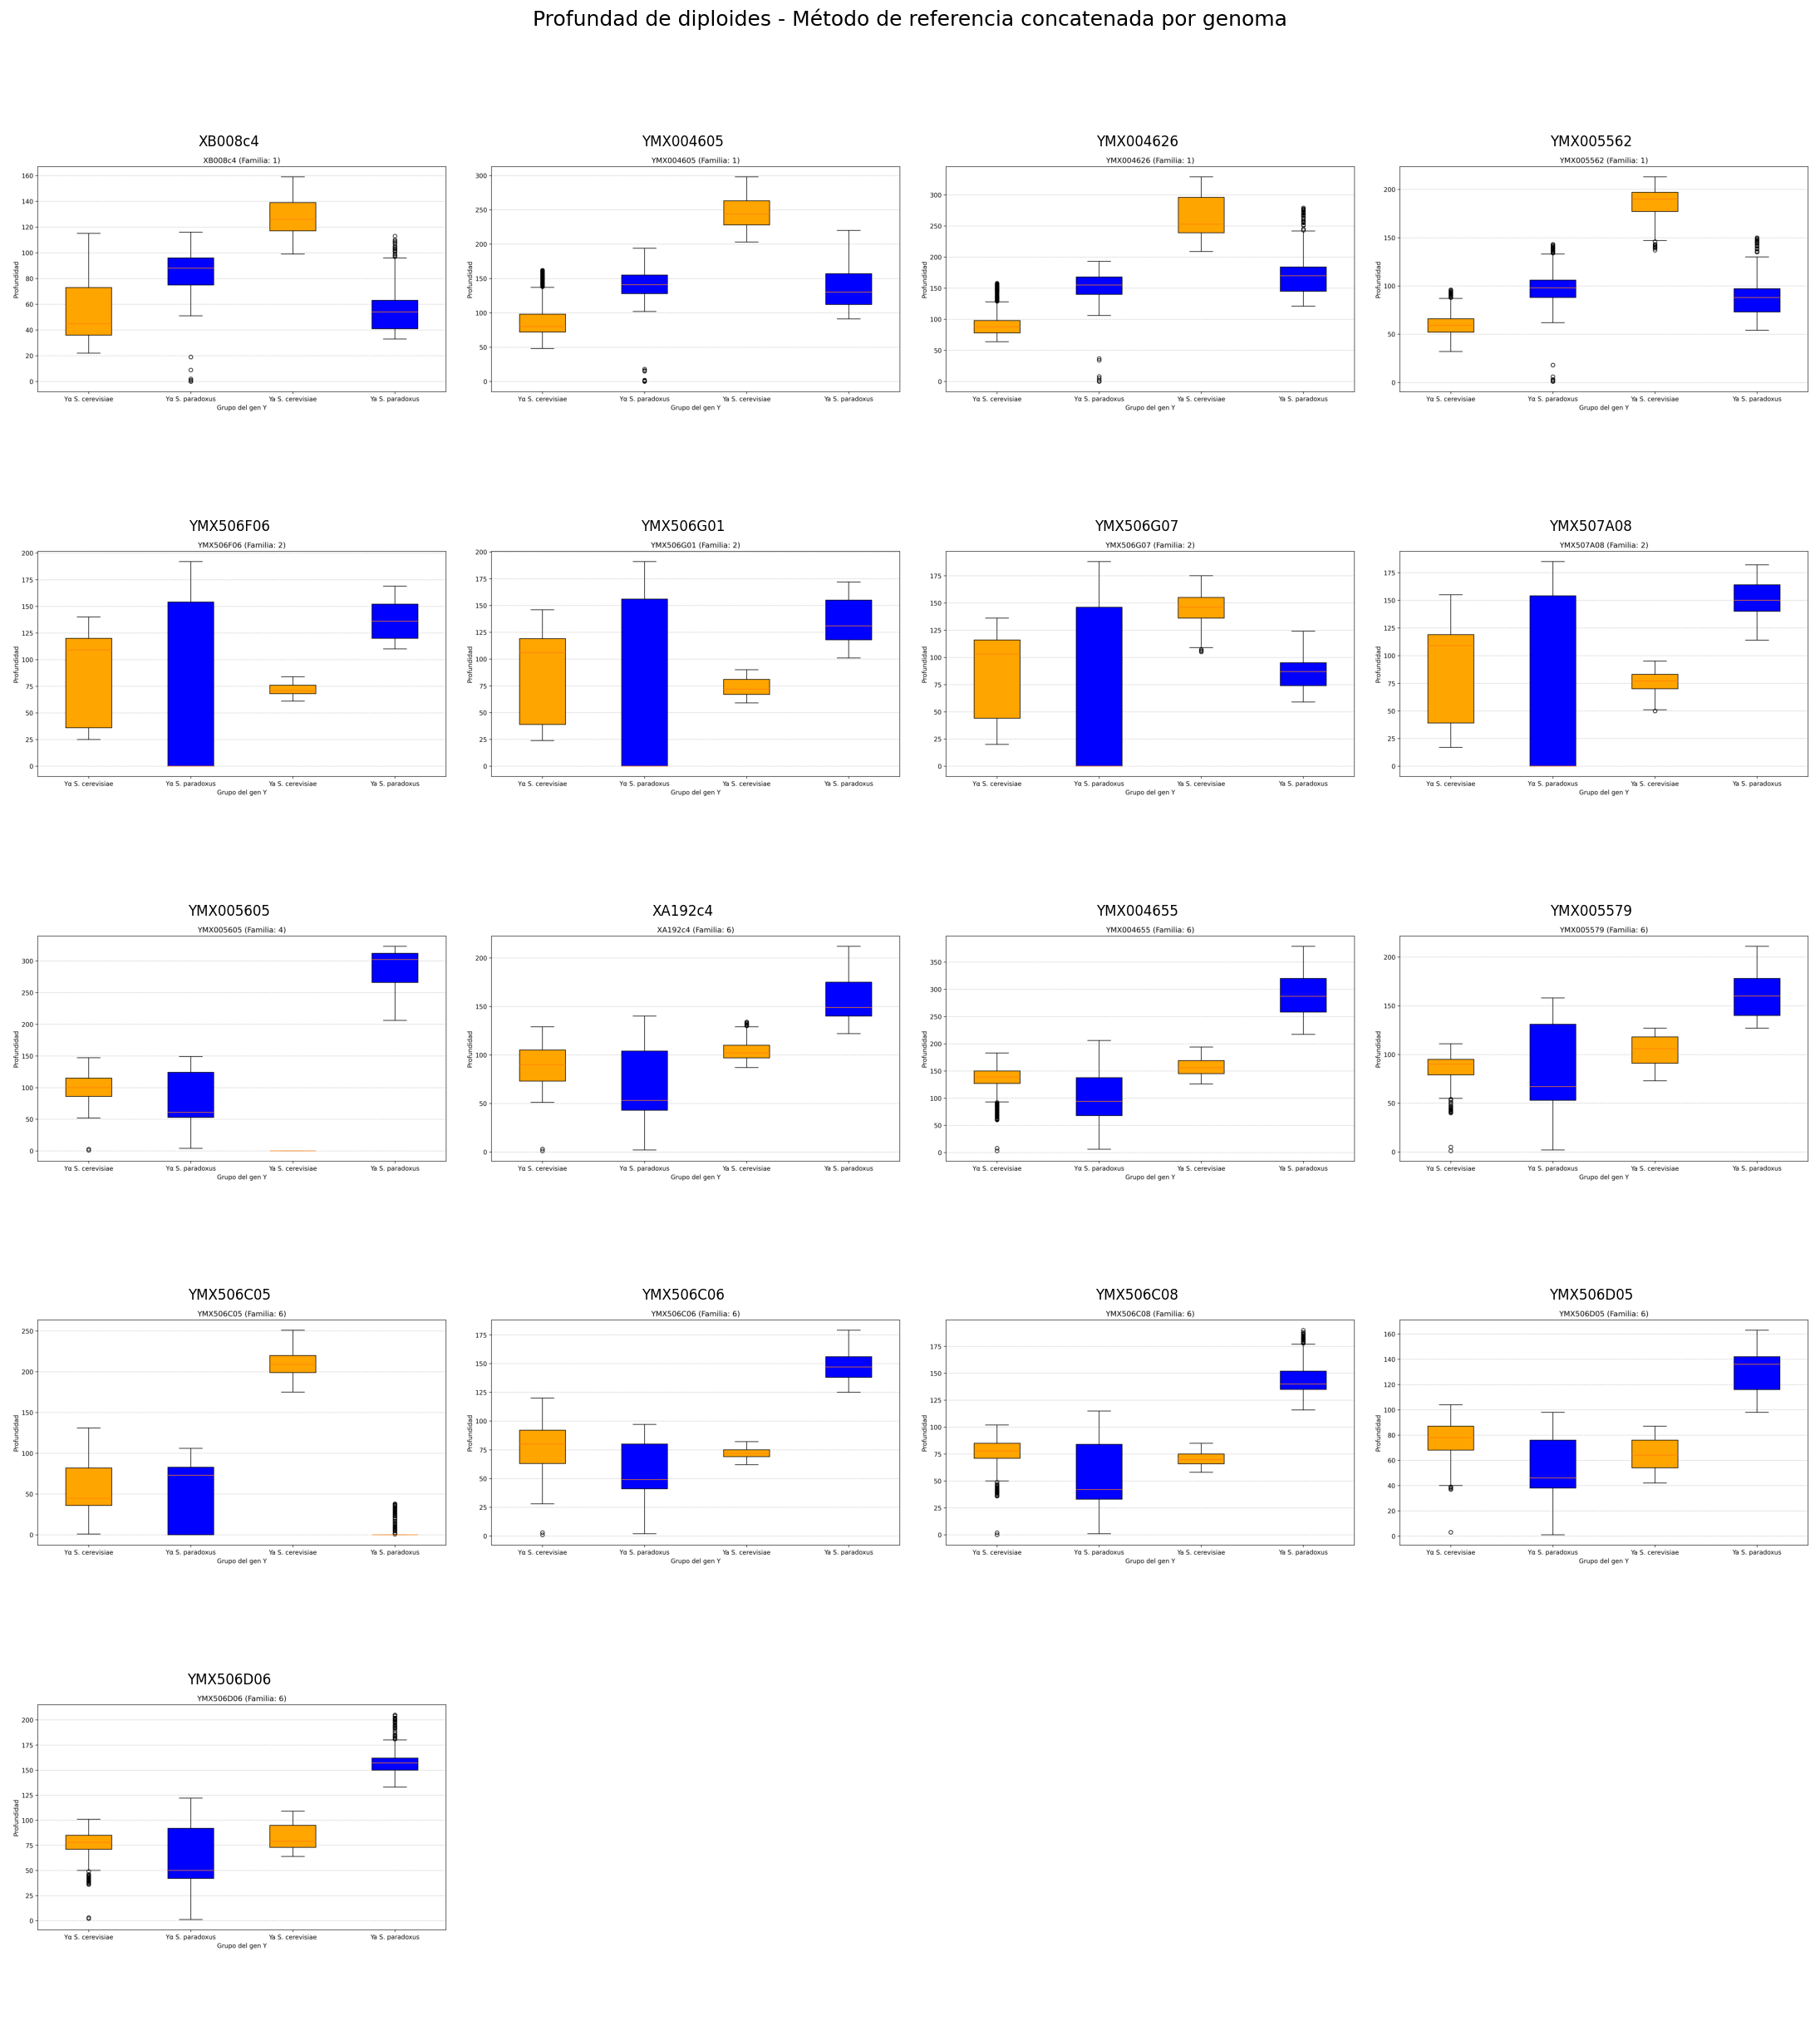

In [107]:
fig_sub = subplot_desde_png(
    carpeta_imagenes="imagenesM2",
    lista_ids=lista_hibridos_Dip_M2,
    titulo="Profundad de diploides - Método de referencia concatenada por genoma"
)

fig_sub


In [108]:
lista_hibridos_M2_TRI= [
    "DK003c30",
    "YMX004702",
    "DK002c39",
    "YMX005580",
    "YMX005578",
    "YMX506C10",
    "YMX506H10",
    "YMX507A01",
    "YMX508B12",
    "XA256c15",
    "XB003c8",
    "XB255c12",
    "YMX004544",
    "YMX004587",
    "XB003s8",
    "YMX004548",
    "YMX004593",
    "YMX005560",
    "YMX506F09",
    "YMX005623",
    "YMX005624",
    "XA020c1",
    "YMX004663",
    "YMX005581",
    "XA022c2",
    "XA182c2",
    "XA183c1",
    "XA184c6",
    "YMX004664",
    "YMX004689",
    "YMX004692",
    "YMX005589",
    "YMX005598",
    "YMX506C09",
    "YMX506C11",
    "YMX506D03",
    "YMX506D08",
    "YMX506D09",
    "YMX506E02",
    "YMX506E03",
    "YMX506E04",
    "YMX506H11",
    "YMX506H12",
    "YMX507A03",
    "YMX005536"
]


In [109]:
resultados = metodo_genY_lista(
    lista_ids=lista_hibridos_M2_TRI,
    carpeta_depth="/content/depth/depth/",
    archivo_familias="/content/familias_hibridos.csv",
    carpeta_imagenes="imagenesM2_TRI"
)

📁 Carpeta creada: imagenesM2_TRI
📄 Procesando: DK003c30_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2_TRI/DK003c30_genY.png
📄 Procesando: YMX004702_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2_TRI/YMX004702_genY.png
📄 Procesando: DK002c39_CONC_filtrado.depth


...

✅ Guardado: imagenesM2_TRI/YMX506H12_genY.png
📄 Procesando: YMX507A03_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2_TRI/YMX507A03_genY.png
📄 Procesando: YMX005536_CONC_filtrado.depth


/tmp/ipython-input-1760801280.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


✅ Guardado: imagenesM2_TRI/YMX005536_genY.png


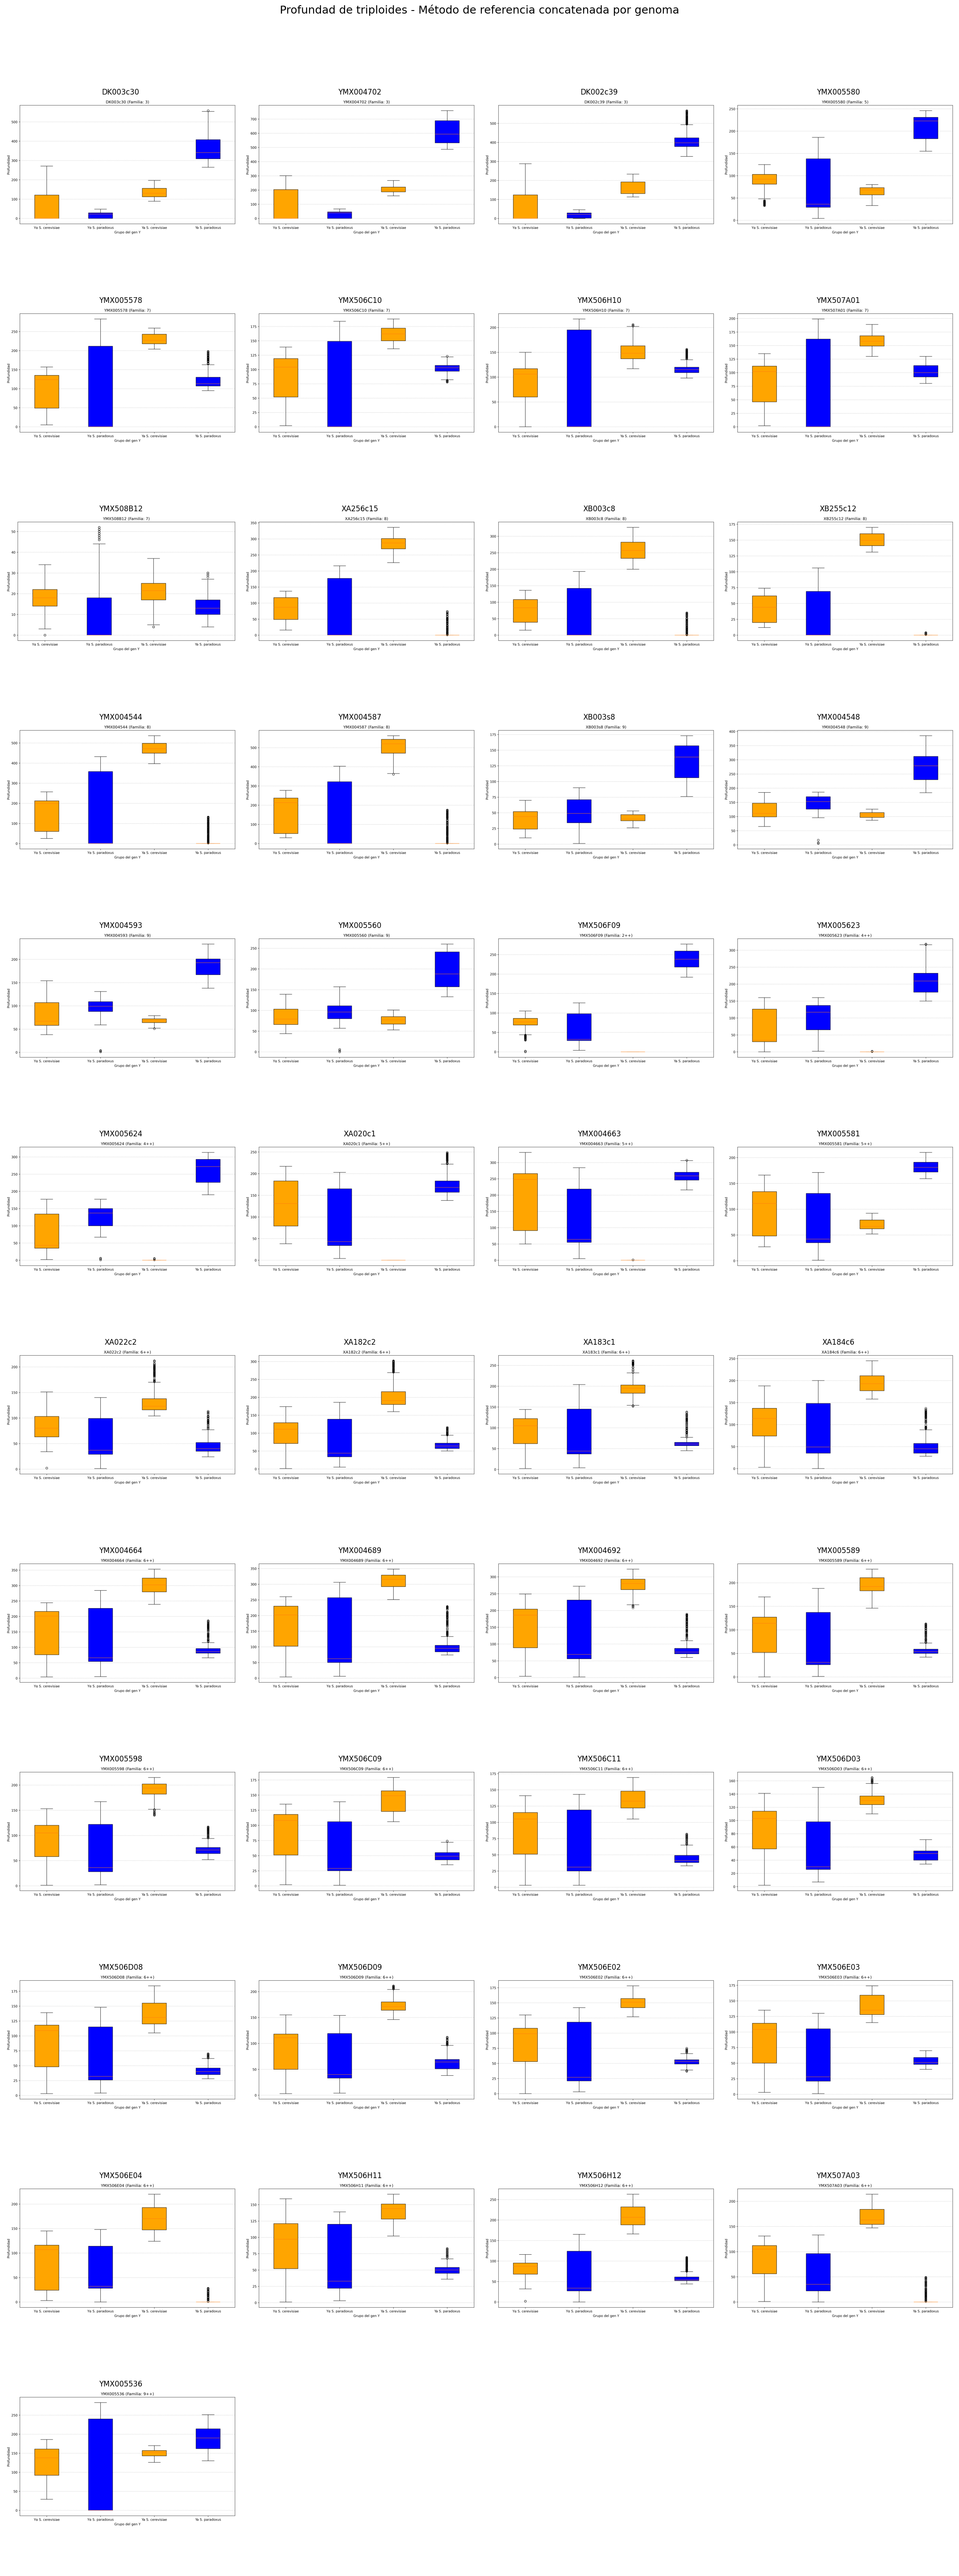

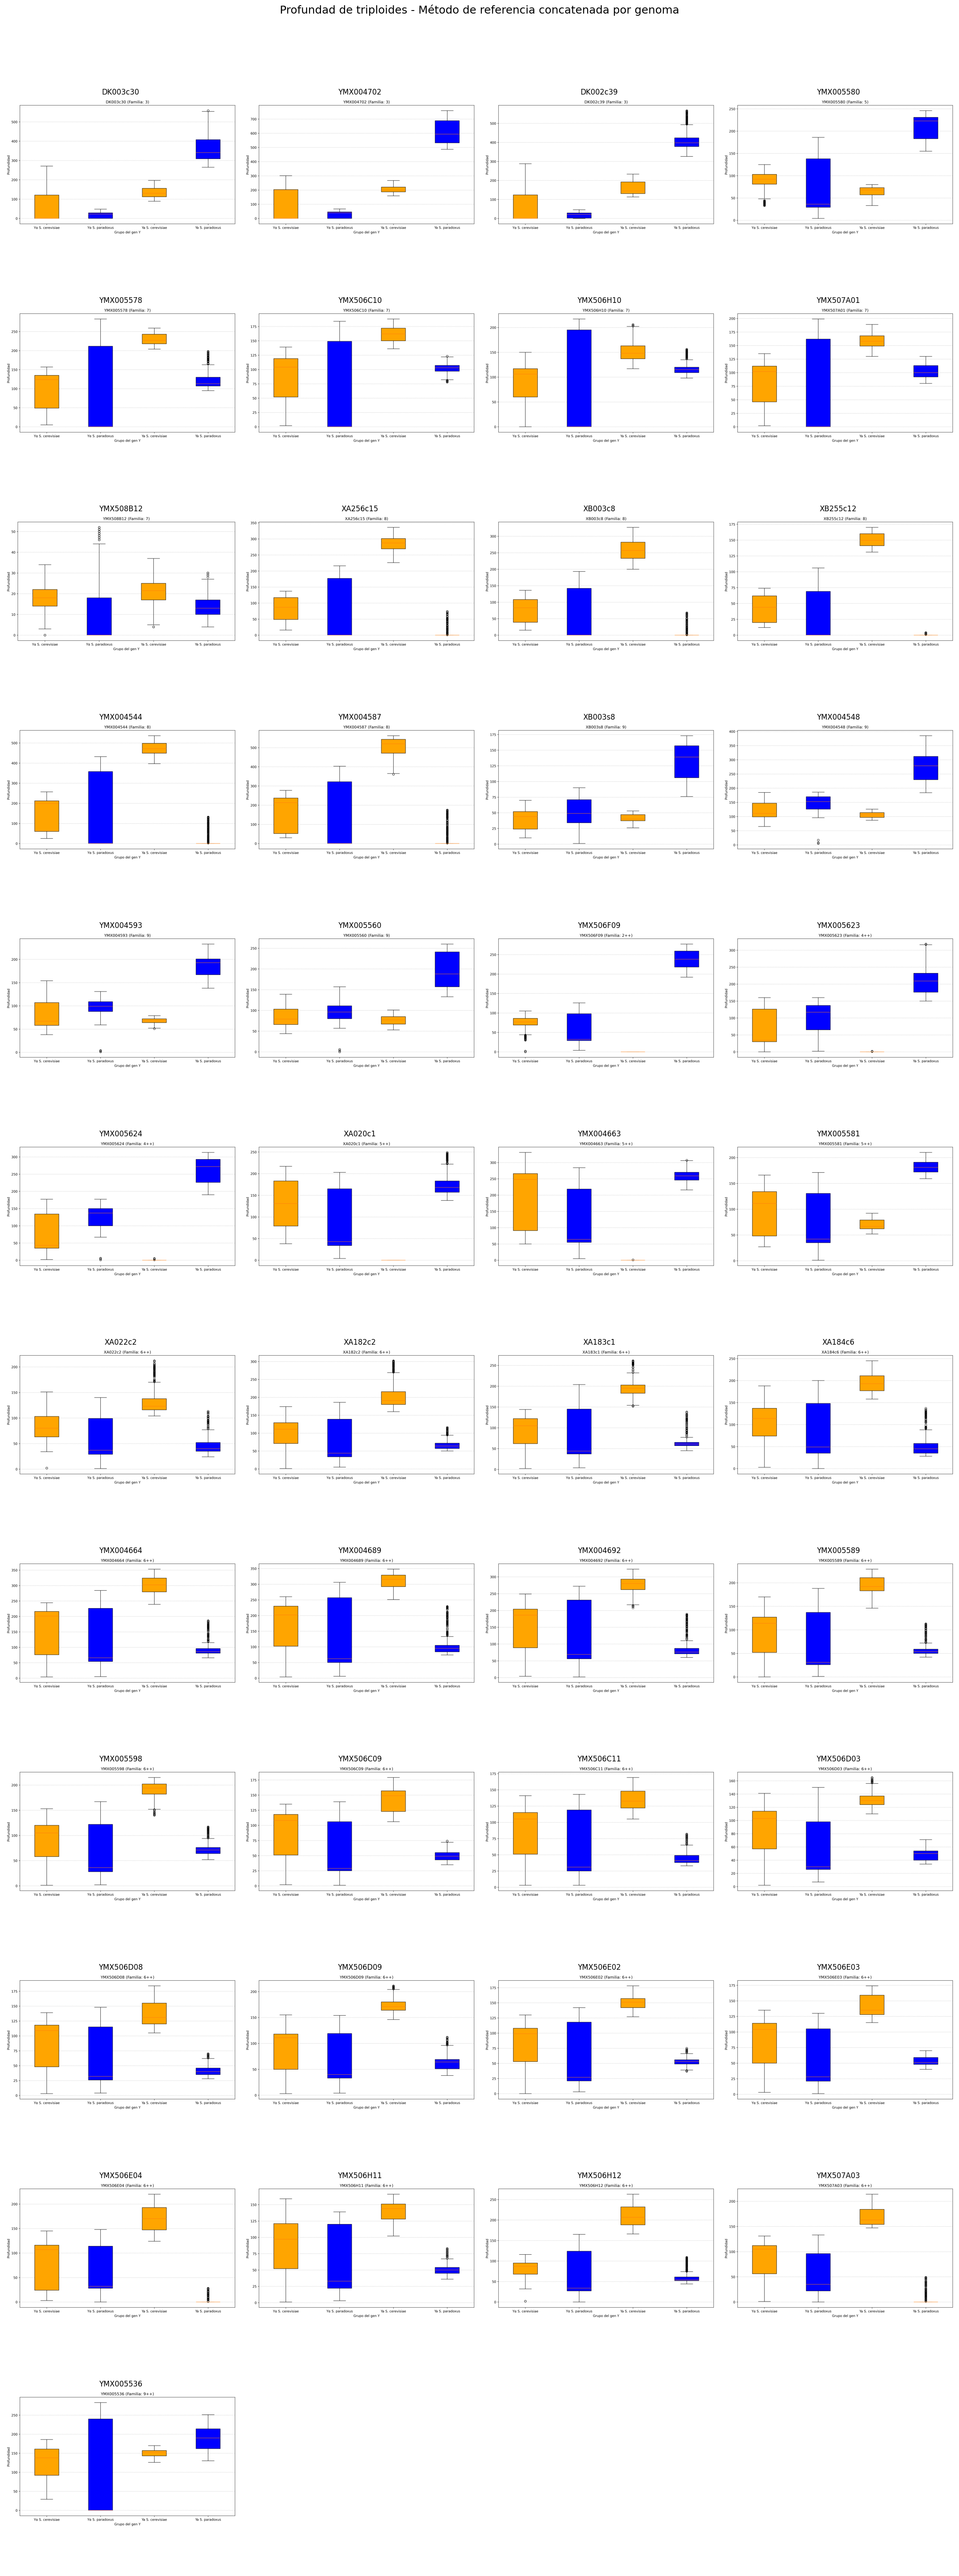

In [110]:
fig_sub = subplot_desde_png(
    carpeta_imagenes="imagenesM2_TRI",
    lista_ids=lista_hibridos_M2_TRI,
    titulo="Profundad de triploides - Método de referencia concatenada por genoma"
)

fig_sub